# Data Battle 2026 — Challenger les 30 minutes
## Un problème de seuil de décision optimal sous contrainte de sécurité stricte

---

### La vraie question opérationnelle

Quand un orage frappe la zone d'alerte, le système attend **30 minutes après le dernier éclair CG** avant de lever l'alerte. Ce délai est un **coussin de sécurité fixe**.

L'opérateur a besoin de savoir, à chaque instant $X$ après le dernier éclair :

> *"À quel point puis-je être confiant que l'orage est vraiment terminé ?"*

Formellement, la variable cible est :

$$p(X \mid \mathbf{x}) = P(T_{\text{res}} \leq X \mid \mathbf{x}) = 1 - S_{\text{res}}(X \mid \mathbf{x})$$
C'est la **probabilité que l'orage soit déjà terminé** $X$ minutes après le dernier éclair.

---

### La règle de décision optimale

L'objectif est de **minimiser le temps d'attente** $X$ tout en garantissant une confiance minimale $1-\alpha$ :

$$X^*(\mathbf{x}) = \min \{X > 0 : p(X \mid \mathbf{x}) \geq 1 - \alpha\}$$
- Contrainte dure : $P(\text{fausse levée}) \leq \alpha$ ne jamais lever trop tôt
- **Objectif** : trouver le plus petit $X^*$ possible

La règle des 30 min suppose implicitement que $P(30 \mid \mathbf{x}) \approx 1$ pour **tous** les orages. Le modèle montrera que ce n'est pas vrai uniformément.

---


. Formalisme mathématique

1.1 Variable aléatoire de durée

Soit $T > 0$ la durée totale d'une alerte (en minutes). On modélise $T$ conditionnellement aux covariables $\mathbf{x}$ observées au déclenchement.

1.2 Les fonctions fondamentales

- Fonction de survie :$$S(t \mid \mathbf{x}) = P(T > t \mid \mathbf{x})$$

- Fonction de hasard :
$f(t \mid \mathbf{x})$ représente la probabilité que l'orage qu'un orage dure t minutes. Par contre, $S(t \mid \mathbf{x})$ représente la probabilité que la durée de l'orage soit supérieure à t.

Comment définir la probabilité qu'a un instant t, l'orage se termine dans un instant suivant infiniment petit ? On introduit une **fonction de hasard**
  
$$h(t \mid \mathbf{x}) = \frac{f(t \mid \mathbf{x})}{S(t \mid \mathbf{x})}, \quad H(t) = \int_0^t h(u)\,du, \quad S(t) = e^{-H(t)}$$
  
1.3 La variable cible : $p(X \mid \mathbf{x})$

Soit $t_L$ le moment du dernier éclair. La durée résiduelle est $T_{\text{res}} = T - t_L \mid T > t_L$.$$\boxed{p(X \mid \mathbf{x}, t_L) = 1 - \frac{S(t_L + X \mid \mathbf{x})}{S(t_L \mid \mathbf{x})}}$$1.4 Règle de décision optimale$$X^*_\alpha(\mathbf{x}, t_L) = \inf\{X > 0 : p(X \mid \mathbf{x}, t_L) \geq 1 - \alpha\}$$

Equivalent à : $S(t_L + X^*) = \alpha \cdot S(t_L)$

1.5 Modèles paramétriques
|Modèle|Hypothèse|Paramètre clé|
|------|---------|-------------|
|Exponentiel | Hasard constant |Sans mémoire|
|Weibull|Hasard monotone| $\gamma > 1$ = épuisement|
|Log-Normal| Queue épaisse |Orages extrêmes | 
Cox | Semi-paramétrique | Aucune hypothèse sur $h_0$| 

1.6 Modèle AFT(accelerated failure time) $$\log T = \mathbf{x}^\top\boldsymbol{\beta} + \sigma\varepsilon$$

Les $\exp(\beta_j)$ sont des facteurs multiplicatifs sur la durée.
Références

- Cox (1972). J. Royal Stat. Soc. B, 34(2).Kalbfleisch & Prentice (2002). 
- Statistical Analysis of Failure Time Data. Wiley
- .Kleinbaum & Klein (2012). Survival Analysis. Springer.
- Therneau & Grambsch (2000). Modeling Survival Data. Springer.

###  Le lien entre survie et seuil de décision

La règle des 30 min est équivalente à choisir $X^* = 30$ identique pour **tous** les orages.

Le modèle calcule $p(X\mid \mathbf{x})$ individuellement et trouve le plus petit $X^*$ qui garantit la même confiance .

| Orage | $p(30\mid \mathbf{x})$ | $X^*_{95\%}$ | Bilan |
|-------|--------------------------|--------------|-------|
| Eclair isolé hivernal | ≈ 1.00 | ~5 min | 25 min de trop avec la règle actuelle |
| Orage modéré | ≈ 0.92 | ~20 min | 10 min de trop |
| Orage intense estival | ≈ 0.75 | ~40 min | **30 min insuffisantes !** |

La règle adaptative fait **les deux sens** : raccourcir pour les orages courts, allonger pour les intenses.

---


## 2. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import warnings

# Librairies de survie
try:
    from lifelines import (
        KaplanMeierFitter, WeibullFitter, LogNormalFitter,
        LogLogisticFitter, ExponentialFitter,
        CoxPHFitter, WeibullAFTFitter
    )
    from lifelines.statistics import logrank_test, multivariate_logrank_test
    from lifelines.utils import concordance_index
    print('lifelines ✓')
except ImportError:
    print('lifelines non installé — exécuter : pip install lifelines')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librairies chargées ✓')

lifelines ✓
Librairies chargées ✓


---
## 3. Chargement et construction du dataset de survie

L'unité statistique est ici **l'alerte** (et non l'éclair). On construit une ligne par alerte avec :
- La **durée** $T$ (variable de survie, en minutes)
- Les **covariables** $\mathbf{x}$ observées au déclenchement ou agrégées sur l'alerte

### Attention sur le format des dates
Les dates sont au format UTC avec timezone. Le calcul des durées nécessite une conversion préalable (`.dt.total_seconds()`) après un `.diff()` groupé, sinon pandas lève des erreurs de type ou de soustraction de `Timedelta` avec timezone.

---
Ce code charge les 507 071 éclairs bruts, corrige le format des dates pour pouvoir faire des calculs de durée, puis isole les ~56 000 éclairs qui se trouvent dans la zone d'alerte des 20 km — ce sont les seuls qui entrent dans la modélisation de survie.

In [ ]:
# ── Chargement ─────────────────────────────────────────────────────────────
path = r"C:\Users\LOIC TCHOUPE\Downloads\data_train_databattle2026\data_train_databattle2026\segment_alerts_all_airports_train.csv"
df = pd.read_csv(path, parse_dates=['date'])

# Normalisation timezone → UTC-aware
df['date'] = pd.to_datetime(df['date'], utc=True)

# Zone alerte uniquement (CG < 20 km)
df_alert = df[df['airport_alert_id'].notna()].copy()
df_alert['airport_alert_id'] = df_alert['airport_alert_id'].astype(int)
df_alert = df_alert.sort_values(['airport', 'airport_alert_id', 'date'])

print(f'Éclairs en zone alerte : {len(df_alert):,}')
print(f'Colonnes disponibles : {list(df_alert.columns)}')

Éclairs en zone alerte : 56,599
Colonnes disponibles : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


In [25]:
print(df.head())

print(len(df_alert.columns))


   lightning_id  lightning_airport_id                      date     lon  \
0             1                     1 2016-01-02 14:53:36+00:00  9.0559   
1             2                     2 2016-01-02 14:53:36+00:00  9.0236   
2             3                     3 2016-01-02 21:22:53+00:00  8.8585   
3             4                     4 2016-01-02 21:22:53+00:00  8.8517   
4             5                     5 2016-01-02 21:24:46+00:00  8.8728   

       lat  amplitude  maxis  icloud       dist    azimuth  airport  \
0  42.0826      -9.90    0.3   False  27.360653  57.852343  Ajaccio   
1  42.0953      -3.33    0.2    True  26.383167  52.117828  Ajaccio   
2  42.0456     -18.68    0.4    True  14.313391  24.500543  Ajaccio   
3  42.0517      -7.51    0.2   False  14.794117  20.854458  Ajaccio   
4  42.0494      -6.01    0.2   False  15.124224  29.058471  Ajaccio   

   airport_alert_id is_last_lightning_cloud_ground  
0               NaN                            NaN  
1               

Pour continuer le travail de modélisation, la construction de la base est primordiale :

1. Calcul de la variable cible $T$ (duration_min)
Elle groupe les éclairs par identifiant d'alerte (airport_alert_id).Elle calcule l'écart entre le premier et le dernier éclair. Elle gère le cas des "orages à éclair unique" (durée = 0) en ajoutant un $\epsilon = 1$ seconde. C'est crucial car les modèles comme Weibull ou Log-Normal ne supportent pas une durée de 0 (le log de 0 est indéfini).

2. On transforme l'heure et le mois en Sinus/Cosinus.
Pourquoi ? Pour que le modèle comprenne que 23h et 00h sont proches. Sans cela, le modèle verrait un saut  immense entre 23 et 00, alors qu'en réalité, il n'y a qu'une heure d'écart.
On utilise les formules suivantes :

$$\sin_{\text{hour}} = \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$
$$\cos_{\text{hour}} = \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

3. Elle enregistre la distance, l'azimut et l'amplitude du tout premier éclair de l'alerte. Cela permet au modèle de répondre à : "Si ça commence fort et très près, est-ce que ça dure plus longtemps ?"
   
4. Elle applique un log1p (logarithme de $1+x$) sur les durées et le nombre d'éclairs.
   


Au total, on crée 30 autres variables :

- Volume : Nombre total d'éclairs par orage

- sur chaque orage on regarde le pourcentage d'éclairs à amplitude posituve, plus c'est élévé, plus l'éclair se dissipe

-  Elle calcule l'inter-temps moyen (inter_mean)(On trie les éclairs par heure. On calcule l'écart de temps entre l'éclair $n$ et l'éclair $n+1$.On fait la moyenne de tous ces écarts.)

In [3]:
# ── Construction du dataset alerte-niveau ──────────────────────────────────
#
# TRAITEMENT DES DATES (point délicat) :
# df_alert['date'] est tz-aware (UTC). Pour calculer des durées :
#   - .groupby().agg({'date': ['min','max']}) → donne des Timestamps UTC
#   - La différence (max - min) donne un Timedelta → .total_seconds() / 60
#   - NE PAS faire .dt.tz_localize() une 2e fois (déjà localisé)

def build_alert_dataset(df_alert):
    """
    Construit un dataset à l'échelle alerte avec :
    - durée T (minutes) entre premier et dernier éclair CG
    - covariables du déclenchement et agrégées
    """
    grp = df_alert.groupby(['airport', 'airport_alert_id'])
    
    # ── Timing ────────────────────────────────────────────────────────────
    timing = grp['date'].agg(['min', 'max']).reset_index()
    timing.columns = ['airport', 'airport_alert_id', 'debut', 'fin']
    
    # Durée totale : (fin - debut) en minutes
    # Timedelta entre deux Timestamps UTC-aware → .total_seconds() est sûr
    timing['duration_min'] = (timing['fin'] - timing['debut']).dt.total_seconds() / 60.0
    
    # ── Traitement des durées nulles (alertes à éclair unique) ────────────
    # Les modèles paramétriques (Weibull, Log-Normal, etc.) exigent T > 0.
    # Les alertes avec un seul éclair CG ont debut == fin → duration = 0.
    # Deux options :
    #   (a) Les supprimer : biais si les alertes courtes sont nombreuses
    #   (b) Ajouter un epsilon = 1/60 min (1 seconde) — choix retenu ici
    # Ce choix est justifié physiquement : la durée minimale observable
    # correspond à la résolution temporelle de la mesure (~1 s).
    n_zero = (timing['duration_min'] == 0).sum()
    timing['duration_min'] = timing['duration_min'].clip(lower=1/60)  # ε = 1 seconde
    # On flag ces alertes pour analyse ultérieure
    timing['single_strike'] = (timing['duration_min'] <= 1/60 + 1e-9).astype(int)
    print(f'  → {n_zero} alertes à éclair unique (durée=0) corrigées avec ε=1s')
    
    # ── Covariables temporelles (du déclenchement) ─────────────────────
    first = grp.first().reset_index()
    timing['hour_debut']  = timing['debut'].dt.hour
    timing['month_debut'] = timing['debut'].dt.month
    timing['year_debut']  = timing['debut'].dt.year
    timing['season'] = timing['month_debut'].map({
        12:'winter', 1:'winter', 2:'winter',
        3:'spring', 4:'spring', 5:'spring',
        6:'summer', 7:'summer', 8:'summer',
        9:'autumn', 10:'autumn', 11:'autumn'
    })
    timing['hour_sin'] = np.sin(2 * np.pi * timing['hour_debut'] / 24)
    timing['hour_cos'] = np.cos(2 * np.pi * timing['hour_debut'] / 24)
    timing['month_sin'] = np.sin(2 * np.pi * timing['month_debut'] / 12)
    timing['month_cos'] = np.cos(2 * np.pi * timing['month_debut'] / 12)
    
    # ── Covariables spatiales (premier éclair de l'alerte) ─────────────
    first_strike = grp.first()[['dist', 'azimuth', 'amplitude']].reset_index()
    first_strike.columns = ['airport', 'airport_alert_id',
                             'dist_first', 'azimuth_first', 'amp_first']
    first_strike['amp_first_abs'] = first_strike['amp_first'].abs()
    first_strike['amp_first_pos'] = (first_strike['amp_first'] > 0).astype(int)
    
    # ── Covariables agrégées (intensité de l'orage) ────────────────────
    agg_stats = grp.agg(
        n_strikes     = ('lightning_id', 'count'),
        dist_min      = ('dist', 'min'),
        dist_mean     = ('dist', 'mean'),
        amp_abs_max   = ('amplitude', lambda x: x.abs().max()),
        amp_abs_mean  = ('amplitude', lambda x: x.abs().mean()),
        n_positive    = ('amplitude', lambda x: (x > 0).sum()),
    ).reset_index()
    agg_stats['pct_positive'] = agg_stats['n_positive'] / agg_stats['n_strikes']
    
    # ── Calcul de l'inter-temps moyen (proxy d'intensité) ──────────────
    # NOTE TECHNIQUE : .diff() sur dates tz-aware → Timedelta. Il faut
    # appliquer .dt.total_seconds() AVANT de faire la moyenne, sinon
    # pandas peut lever TypeError selon la version.
    df_alert_copy = df_alert.copy()
    df_alert_copy['inter_s'] = (
        df_alert_copy
        .groupby(['airport', 'airport_alert_id'])['date']
        .diff()
        .dt.total_seconds()   # ← conversion explicite avant .mean()
    )
    inter_stats = df_alert_copy.groupby(['airport', 'airport_alert_id'])['inter_s'].agg(
        inter_mean='mean', inter_median='median', inter_max='max'
    ).reset_index()
    
    # ── Merge de toutes les tables ─────────────────────────────────────
    df_surv = (
        timing
        .merge(first_strike, on=['airport', 'airport_alert_id'])
        .merge(agg_stats,    on=['airport', 'airport_alert_id'])
        .merge(inter_stats,  on=['airport', 'airport_alert_id'])
    )
    
    # Indicateur de censure (ici toujours 1 = événement observé)
    df_surv['event'] = 1
    
    # Log-durée (plus stable numériquement)
    df_surv['log_duration'] = np.log1p(df_surv['duration_min'])
    df_surv['log_n_strikes'] = np.log1p(df_surv['n_strikes'])
    df_surv['log_inter_mean'] = np.log1p(df_surv['inter_mean'].fillna(0))
    
    return df_surv

df_surv = build_alert_dataset(df_alert)

print(f'Dataset de survie : {df_surv.shape}')
print(f'Alertes : {len(df_surv):,}')
print(f'\nStatistiques de la durée T (minutes) :')
print(df_surv['duration_min'].describe().round(2).to_string())

  → 966 alertes à éclair unique (durée=0) corrigées avec ε=1s
Dataset de survie : (2627, 33)
Alertes : 2,627

Statistiques de la durée T (minutes) :
count    2627.00
mean       29.91
std        50.28
min         0.02
25%         0.02
50%         8.92
75%        38.59
max       578.72


In [26]:
print(df_surv.columns)

Index(['airport', 'airport_alert_id', 'debut', 'fin', 'duration_min',
       'single_strike', 'hour_debut', 'month_debut', 'year_debut', 'season',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dist_first',
       'azimuth_first', 'amp_first', 'amp_first_abs', 'amp_first_pos',
       'n_strikes', 'dist_min', 'dist_mean', 'amp_abs_max', 'amp_abs_mean',
       'n_positive', 'pct_positive', 'inter_mean', 'inter_median', 'inter_max',
       'event', 'log_duration', 'log_n_strikes', 'log_inter_mean',
       'season_ord'],
      dtype='object')


## Dictionnaire de variables
---

| Variable | Définition |
|:---|:---|
| $airport$ | Nom de l'aéroport |
| $airport\_alert\_id$ | Identifiant unique de l'alerte |
| $debut\ /\ fin$ | Horaires UTC du premier et dernier éclair |
| $duration\_min$ | Durée totale $T$ de l'alerte (en min) |
| $log\_duration$ | Logarithme de la durée $\log(1+T)$ |
| $event$ | Indicateur de fin d'événement (1 = observé) |
| $single\_strike$ | Flag pour les alertes à un seul éclair ($\epsilon=1s$) |
| $hour\_debut$ | Heure de début (0-23) |
| $month\_debut$ | Mois de début (1-12) |
| $season$ | Saison (winter, spring, summer, autumn) |
| $hour\_sin\ /\ hour\_cos$ | Encodage cyclique de l'heure |
| $month\_sin\ /\ month\_cos$ | Encodage cyclique du mois |
| $dist\_first$ | Distance du 1er éclair au centre (km) |
| $azimuth\_first$ | Angle d'arrivée du 1er éclair (0-360°) |
| $dist\_min$ | Distance de l'éclair le plus proche |
| $dist\_mean$ | Distance moyenne des éclairs |
| $amp\_first$ | Amplitude du 1er éclair (kA) |
| $amp\_abs\_max$ | Amplitude maximale de l'alerte |
| $amp\_abs\_mean$ | Amplitude moyenne de l'alerte |
| $n\_strikes$ | Nombre total d'éclairs |
| $log\_n\_strikes$ | Logarithme du nombre d'éclairs |
| $n\_positive$ | Nombre d'éclairs positifs (+) |
| $pct\_positive$ | Ratio d'éclairs positifs (indice de fin d'orage) |
| $inter\_mean$ | Temps de silence moyen entre éclairs (s) |
| $log\_inter\_mean$ | Logarithme du silence moyen |
| $inter\_max$ | Silence maximum observé (s) |

In [4]:
# ── Aperçu du dataset de survie ────────────────────────────────────────────
cols_show = ['airport', 'duration_min', 'n_strikes', 'dist_first',
             'amp_first_abs', 'inter_mean', 'hour_debut', 'season', 'year_debut']
display(df_surv[cols_show].head(10))
print(f'\nAlertes par aéroport :')
print(df_surv['airport'].value_counts().to_string())
print(f'\nAlertes par saison :')
print(df_surv['season'].value_counts().to_string())

,airport,duration_min,n_strikes,dist_first,amp_first_abs,inter_mean,hour_debut,season,year_debut
0,Ajaccio,6.016667,5,14.794117,7.51,90.250000,21,winter,2016
1,Ajaccio,0.016667,1,12.875968,13.74,NaN,6,winter,2016
2,Ajaccio,0.016667,1,6.347720,25.34,NaN,7,winter,2016
3,Ajaccio,0.016667,1,3.033382,24.81,NaN,14,winter,2016
4,Ajaccio,0.016667,1,17.927176,11.78,NaN,14,winter,2016
5,Ajaccio,52.250000,28,10.630360,14.45,116.111111,14,winter,2016
6,Ajaccio,0.016667,2,17.659939,45.23,0.000000,17,winter,2016
7,Ajaccio,39.766667,27,18.338799,94.46,91.769231,11,spring,2016
8,Ajaccio,13.400000,6,16.301465,31.47,160.800000,6,spring,2016
9,Ajaccio,0.016667,1,15.292930,62.11,NaN,13,spring,2016



Alertes par aéroport :
airport
Pise        769
Biarritz    590
Bastia      532
Ajaccio     530
Nantes      206

Alertes par saison :
season
summer    821
autumn    807
spring    580
winter    419


###  Ce que contient le dataset

`duration_min` = $T$ = durée réelle de l'orage. La règle actuelle lève l'alerte à `duration_min + 30`.

Le modèle proposera `duration_min + X*(x)` pour chaque alerte individuellement.

> **Note :** les alertes à éclair unique (T=0) sont corrigées avec ε = 1 seconde — elles représentent le cas idéal où X* ≈ 0.

---


---
## 4. Analyse exploratoire de la durée

Avant de modéliser, on vérifie la distribution de $T$ et son adéquation avec les hypothèses des différents modèles paramétriques.

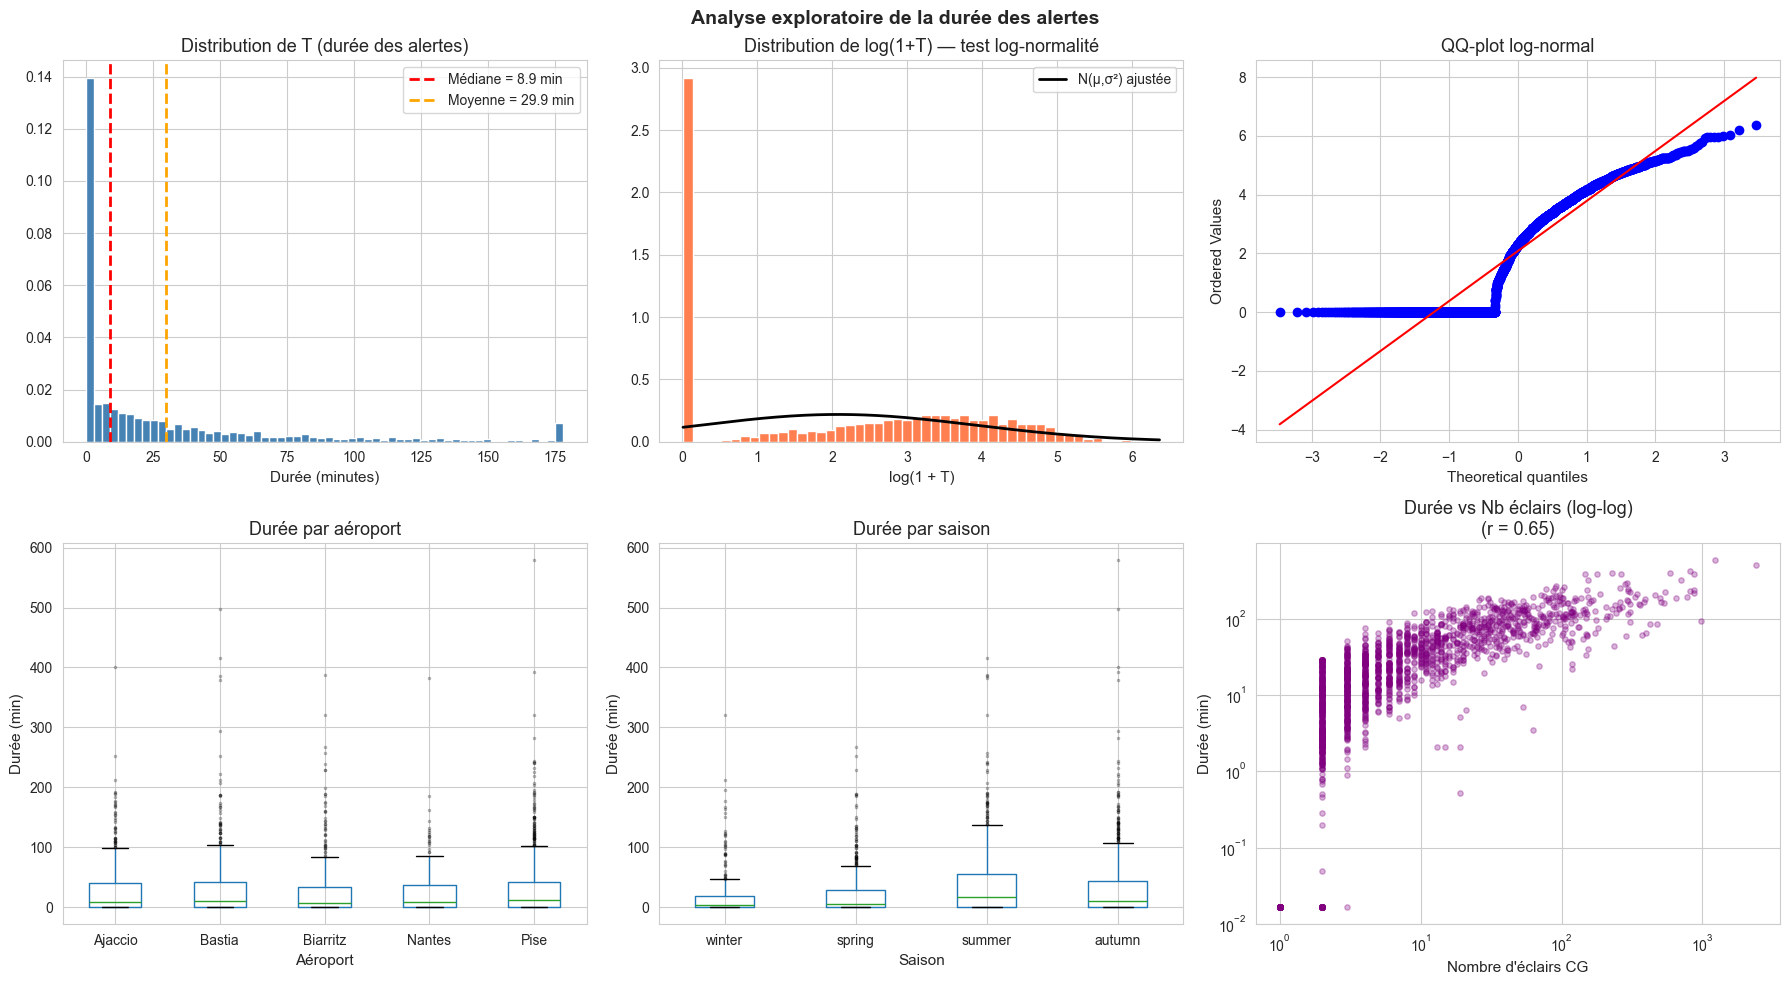

Test de Shapiro-Wilk sur log(1+T) : stat=0.8638, p=0.0000


In [28]:
T = df_surv['duration_min']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution brute de T
T_clip = T.clip(upper=T.quantile(0.98))
axes[0, 0].hist(T_clip, bins=60, color='steelblue', edgecolor='white', density=True)
axes[0, 0].axvline(T.median(), color='red', ls='--', lw=2, label=f'Médiane = {T.median():.1f} min')
axes[0, 0].axvline(T.mean(), color='orange', ls='--', lw=2, label=f'Moyenne = {T.mean():.1f} min')
axes[0, 0].set_title('Distribution de T (durée des alertes)')
axes[0, 0].set_xlabel('Durée (minutes)')
axes[0, 0].legend()

# 2. Distribution de log(T) — test de log-normalité
logT = np.log1p(T)
axes[0, 1].hist(logT, bins=50, color='coral', edgecolor='white', density=True)
x_grid = np.linspace(logT.min(), logT.max(), 200)
mu_log, std_log = logT.mean(), logT.std()
axes[0, 1].plot(x_grid, stats.norm.pdf(x_grid, mu_log, std_log),
                'k-', lw=2, label='N(μ,σ²) ajustée')
axes[0, 1].set_title('Distribution de log(1+T) — test log-normalité')
axes[0, 1].set_xlabel('log(1 + T)')
axes[0, 1].legend()

# 3. QQ-plot log-normal
stats.probplot(logT, dist='norm', plot=axes[0, 2])
axes[0, 2].set_title('QQ-plot log-normal')

# 4. Distribution par aéroport (boxplot)
df_surv.boxplot(column='duration_min', by='airport', ax=axes[1, 0],
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[1, 0].set_title('Durée par aéroport')
axes[1, 0].set_xlabel('Aéroport')
axes[1, 0].set_ylabel('Durée (min)')
plt.sca(axes[1, 0])
plt.title('Durée par aéroport')

# 5. Distribution par saison
season_order = ['winter', 'spring', 'summer', 'autumn']
df_surv['season_ord'] = pd.Categorical(df_surv['season'], categories=season_order, ordered=True)
df_surv.boxplot(column='duration_min', by='season_ord', ax=axes[1, 1],
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[1, 1].set_title('Durée par saison')
axes[1, 1].set_xlabel('Saison')
axes[1, 1].set_ylabel('Durée (min)')
plt.sca(axes[1, 1])
plt.title('Durée par saison')

# 6. Durée vs nombre d'éclairs
axes[1, 2].scatter(df_surv['n_strikes'], df_surv['duration_min'],
                   alpha=0.3, s=15, color='purple')
axes[1, 2].set_xlabel('Nombre d\'éclairs CG')
axes[1, 2].set_ylabel('Durée (min)')
axes[1, 2].set_xscale('log')
axes[1, 2].set_yscale('log')
axes[1, 2].set_title('Durée vs Nb éclairs (échelle log-log)')
corr = df_surv[['n_strikes', 'duration_min']].corr().iloc[0, 1]
axes[1, 2].set_title(f'Durée vs Nb éclairs (log-log)\n(r = {corr:.2f})')

plt.suptitle('Analyse exploratoire de la durée des alertes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Test de normalité de log(T)
stat, pval = stats.shapiro(logT.sample(min(len(logT), 5000), random_state=42))
print(f'Test de Shapiro-Wilk sur log(1+T) : stat={stat:.4f}, p={pval:.4f}')


- Le premier graphique montre des infrmations essentielles sur la duration : on remarque que la moyenne est supérieure à la médiane, on parle d'asymétrie positive. Donc la loi des durations est à queue lourde. 
- Le second graphique avec le log, aide à comprendre que l'on peut ajuster cette distribution avec une loi log normale ou de weibul
- Le QQ,plot n'est pas satisfaisant
- On observe que les boxplots des durée par aéroports sont assez similaire mais les aéroports de Pise et Bastia présente des queues plus lourde. 
- Par ailleurs, on observe des valeurs beaucoup plus grande de la duraion en autumn et en été et baucoup plus faible en hiver
- On observe une relation assez linéaire entre le nombre d'éclairss et la duration : plus il y a d'éclairs, plus l'orage dure

> **Note** Les log duration ne suivent pas une loi log normale, p value inférieure à 0.05

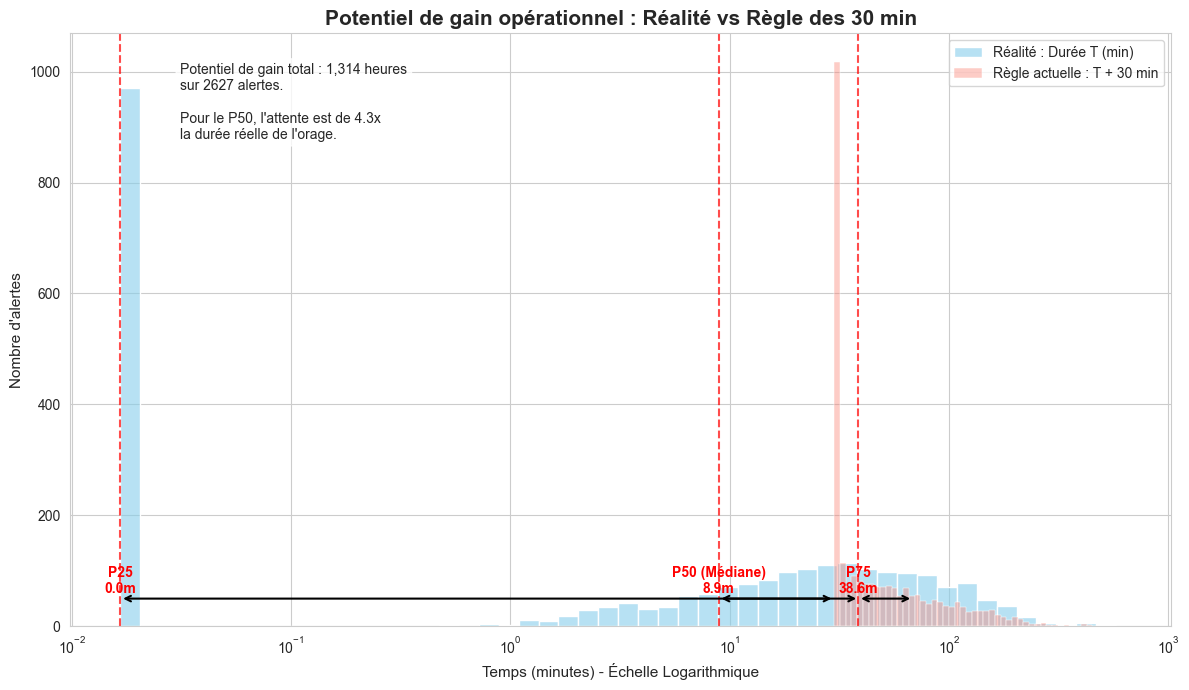

In [ ]:
import matplotlib.patches as mpatches

# 1. Calcul des métriques de gain
df_surv['regle_30min'] = df_surv['duration_min'] + 30
gain_total_heures = (df_surv['regle_30min'] - df_surv['duration_min']).sum() / 60

# 2. Création de la figure
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Histogrammes superposés
# On utilise log(1+T) pour mieux voir la différence sur les orages courts
sns.histplot(df_surv['duration_min'], bins=50, color='skyblue', label='Réalité : Durée T (min)', alpha=0.6, log_scale=True)
sns.histplot(df_surv['regle_30min'], bins=50, color='salmon', label='Règle actuelle : T + 30 min', alpha=0.4, log_scale=True)

p25, p50, p75 = df_surv['duration_min'].quantile([0.25, 0.5, 0.75])
percentiles = [p25, p50, p75]
labels = ['P25', 'P50 (Médiane)', 'P75']

for val, label in zip(percentiles, labels):
    plt.axvline(val, color='red', linestyle='--', alpha=0.7)
    # Flèche de gain
    plt.annotate('', xy=(val, 50), xytext=(val + 30, 50),
                 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    plt.text(val, 60, f'{label}\n{val:.1f}m', color='red', fontweight='bold', ha='center')

plt.title("Potentiel de gain opérationnel : Réalité vs Règle des 30 min", fontsize=15, fontweight='bold')
plt.xlabel("Temps (minutes) - Échelle Logarithmique")
plt.ylabel("Nombre d'alertes")
plt.legend()

txt = (f"Potentiel de gain total : {gain_total_heures:,.0f} heures\n"
       f"sur {len(df_surv)} alertes.\n\n"
       f"Pour le P50, l'attente est de {(9+30)/9:.1f}x\n"
       f"la durée réelle de l'orage.")
plt.text(0.1, 0.95, txt, transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Interprétation 

- Le Mur des Zéros (P25) : La barre bleue à gauche ($10^{-2}$) représente les 966 alertes à éclair unique. Pour elles, la flèche noire est immense : on attend 30 minutes pour un événement qui a duré 1 seconde. C'est ici que la modélisation prend réellement intéet.
- Le Décalage de la Médiane (P50) : À 8.9 min, l'aéroport attend plus de 4 fois la durée réelle.
- La Convergence (P75) : C'est seulement à partir de 30 minutes que la règle actuelle commence à être "raisonnable", car elle protège enfin contre des orages qui ont une vraie durée de vie

Maintenant qu'on comprend l'intéret de faire la modélisation de la duration, let's gooooo

---
## 5. Estimateur de Kaplan-Meier (non paramétrique)

L'estimateur de Kaplan-Meier (Kaplan & Meier, 1958) est l'estimateur non paramétrique de référence pour la fonction de survie. Sans censure, il se réduit à la fonction de répartition empirique complémentaire :
$$\hat{S}_{KM}(t) = \prod_{t_i \leq t} \frac{n_i - d_i}{n_i}$$
où $n_i$ est le nombre d'alertes encore actives juste avant $t_i$ et $d_i$ le nombre finissant à $t_i$.

L'objectif alors est de modéliser la durée de survie d'un orage global par aéroport et par saison.

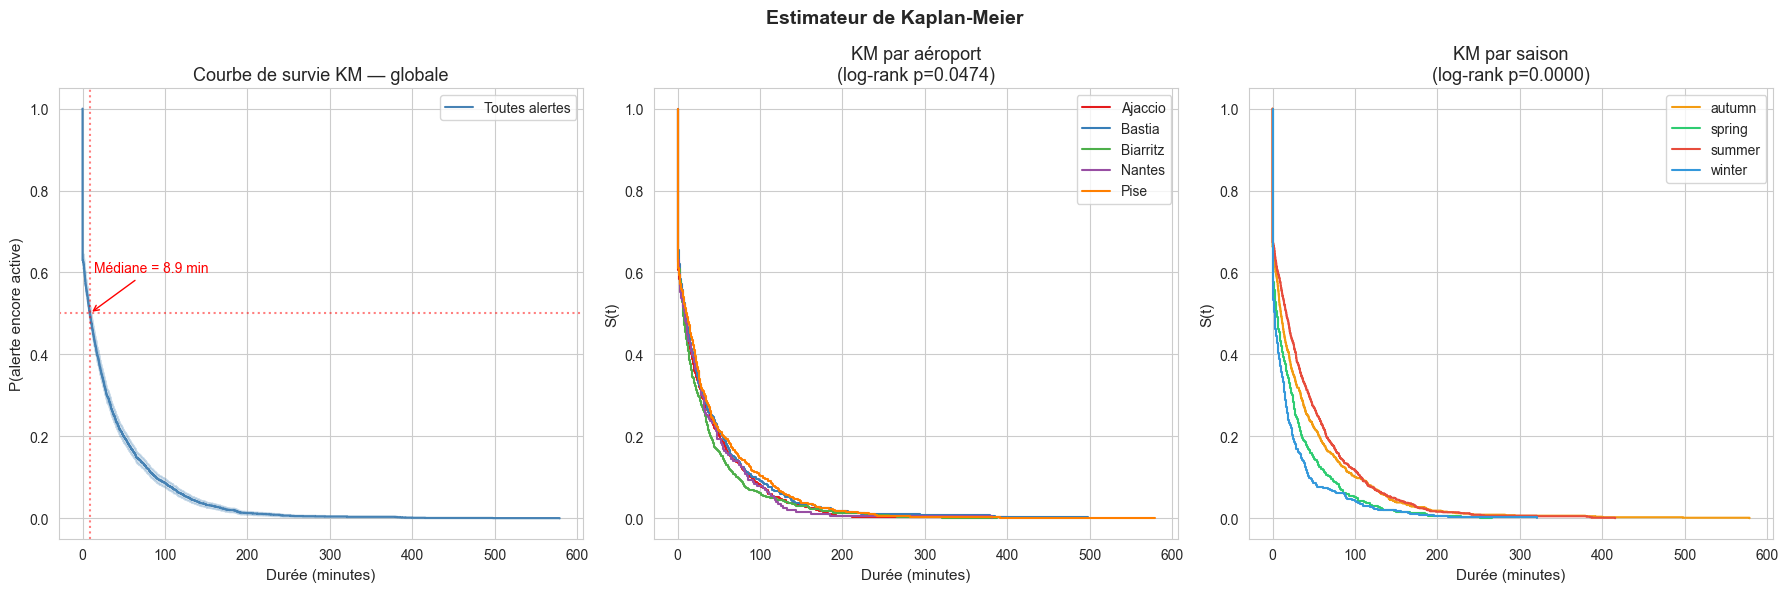

Durée médiane globale : 8.9 minutes


In [6]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. KM global ───────────────────────────────────────────────────────────
kmf = KaplanMeierFitter()
kmf.fit(df_surv['duration_min'], event_observed=df_surv['event'],
        label='Toutes alertes')
kmf.plot_survival_function(ax=axes[0], ci_show=True, color='steelblue')
axes[0].set_title('Courbe de survie KM — globale')
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('P(alerte encore active)')
t_med = kmf.median_survival_time_
axes[0].axhline(0.5, color='red', ls=':', alpha=0.5)
axes[0].axvline(t_med, color='red', ls=':', alpha=0.5)
axes[0].annotate(f'Médiane = {t_med:.1f} min', xy=(t_med, 0.5),
                 xytext=(t_med + 5, 0.6), fontsize=10, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

# ── 2. KM par aéroport ─────────────────────────────────────────────────────
colors_ap = sns.color_palette('Set1', n_colors=5)
for i, (ap, grp) in enumerate(df_surv.groupby('airport')):
    kmf_ap = KaplanMeierFitter()
    kmf_ap.fit(grp['duration_min'], event_observed=grp['event'], label=ap)
    kmf_ap.plot_survival_function(ax=axes[1], ci_show=False, color=colors_ap[i])
axes[1].set_title('Courbes KM par aéroport')
axes[1].set_xlabel('Durée (minutes)')
axes[1].set_ylabel('S(t)')

# Test du log-rank : les courbes diffèrent-elles significativement ?
result_lr = multivariate_logrank_test(
    df_surv['duration_min'], df_surv['airport'], df_surv['event']
)
axes[1].set_title(f'KM par aéroport\n(log-rank p={result_lr.p_value:.4f})')

# ── 3. KM par saison ────────────────────────────────────────────────────────
colors_s = {'winter': '#3498db', 'spring': '#2ecc71', 'summer': '#e74c3c', 'autumn': '#f39c12'}
for s, grp in df_surv.groupby('season'):
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(grp['duration_min'], event_observed=grp['event'], label=s)
    kmf_s.plot_survival_function(ax=axes[2], ci_show=False, color=colors_s.get(s, 'gray'))
result_s = multivariate_logrank_test(
    df_surv['duration_min'], df_surv['season'], df_surv['event']
)
axes[2].set_title(f'KM par saison\n(log-rank p={result_s.p_value:.4f})')
axes[2].set_xlabel('Durée (minutes)')
axes[2].set_ylabel('S(t)')

plt.suptitle('Estimateur de Kaplan-Meier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Durée médiane globale : {kmf.median_survival_time_:.1f} minutes')

Globalement on observe que la courbe d esurvie s'ffrondre dès la première minutes avant de décroire, encore une fois les 30 minutes sont vraiment une grosse perte de temps.

- Les courbes des différents aéroports (Ajaccio, Bastia, Pise, etc.) sont quasiment superposées. On observe par contre un comportement assez différent à Biarritz

- La courbe rouge (summer) est systématiquement au-dessus des autres. En été, la probabilité qu'un orage dure longtemps est beaucoup plus élevée. À 100 minutes, il reste encore des orages actifs en été, alors qu'en hiver (winter, courbe bleue), tout est fini.En été, la probabilité qu'un orage dure longtemps est beaucoup plus élevée. À 100 minutes, il reste encore des orages actifs en été, alors qu'en hiver (winter, courbe bleue), tout est fini.

---
## 6. Ajustement des modèles paramétriques

On compare les modèles **Exponentiel**, **Weibull**, **Log-Normal** et **Log-Logistique** selon leurs critères AIC/BIC et leur qualité d'ajustement graphique (Nelson-Aalen vs modèle).

Le critère AIC est défini par :
$$\text{AIC} = -2\,\hat{\ell} + 2k$$
où $\hat{\ell}$ est la log-vraisemblance maximisée et $k$ le nombre de paramètres.

In [32]:
from lifelines import WeibullFitter, LogNormalFitter, LogLogisticFitter, ExponentialFitter

T_obs = df_surv['duration_min']
E_obs = df_surv['event']

# Vérification : aucune durée nulle ou négative ne doit subsister
assert (T_obs > 0).all(), f'{(T_obs <= 0).sum()} durées nulles ou négatives restantes !'
print(f'Durées vérifiées : min={T_obs.min():.4f} min, max={T_obs.max():.1f} min')
print(f'Alertes à éclair unique (durée ≈ 1s) : {df_surv["single_strike"].sum() if "single_strike" in df_surv.columns else "N/A"}')

models = {
    'Exponentiel': ExponentialFitter(),
    'Weibull':     WeibullFitter(),
    'Log-Normal':  LogNormalFitter(),
    'Log-Logistique': LogLogisticFitter(),
}

fit_results = {}
for name, fitter in models.items():
    fitter.fit(T_obs, event_observed=E_obs, label=name)
    fit_results[name] = {
        'fitter': fitter,
        'AIC': fitter.AIC_,
        'BIC': fitter.BIC_,
        'log_lik': fitter.log_likelihood_,
        'median': fitter.median_survival_time_,
    }

# Tableau comparatif
df_fit_compare = pd.DataFrame(fit_results).T[['log_lik', 'AIC', 'BIC', 'median']]
df_fit_compare.columns = ['Log-vraisemblance', 'AIC', 'BIC', 'Médiane prédite (min)']
df_fit_compare = df_fit_compare.sort_values('AIC')
print('Comparaison des modèles paramétriques (trié par AIC) :')
print(df_fit_compare.round(2).to_string())
print(f'\nMédiane observée : {T_obs.median():.2f} min')

Durées vérifiées : min=0.0167 min, max=578.7 min
Alertes à éclair unique (durée ≈ 1s) : 971
Comparaison des modèles paramétriques (trié par AIC) :
               Log-vraisemblance           AIC           BIC Médiane prédite (min)
Weibull             -8338.977696  16681.955392  16693.702588              3.329105
Log-Normal          -8478.266324  16960.532648  16972.279844              1.664466
Log-Logistique      -8640.032409  17284.064817  17295.812013              2.170797
Exponentiel        -11554.075411  23110.150822   23116.02442             20.732208

Médiane observée : 8.92 min


Pourquoi 3.33 min vs 8.92 min ? C’est le point le plus important. Tous tes modèles paramétriques (Weibull, Log-Normal) prédisent une médiane bien plus basse (1.6 à 3.3 min) que la médiane observée dans les données (8.92 min).La raison : les 971 alertes à éclair unique ont été remplacé par 1 secondes pour éviter les 0 ce qui tire  violemment la courbe vers le bas au tout début.

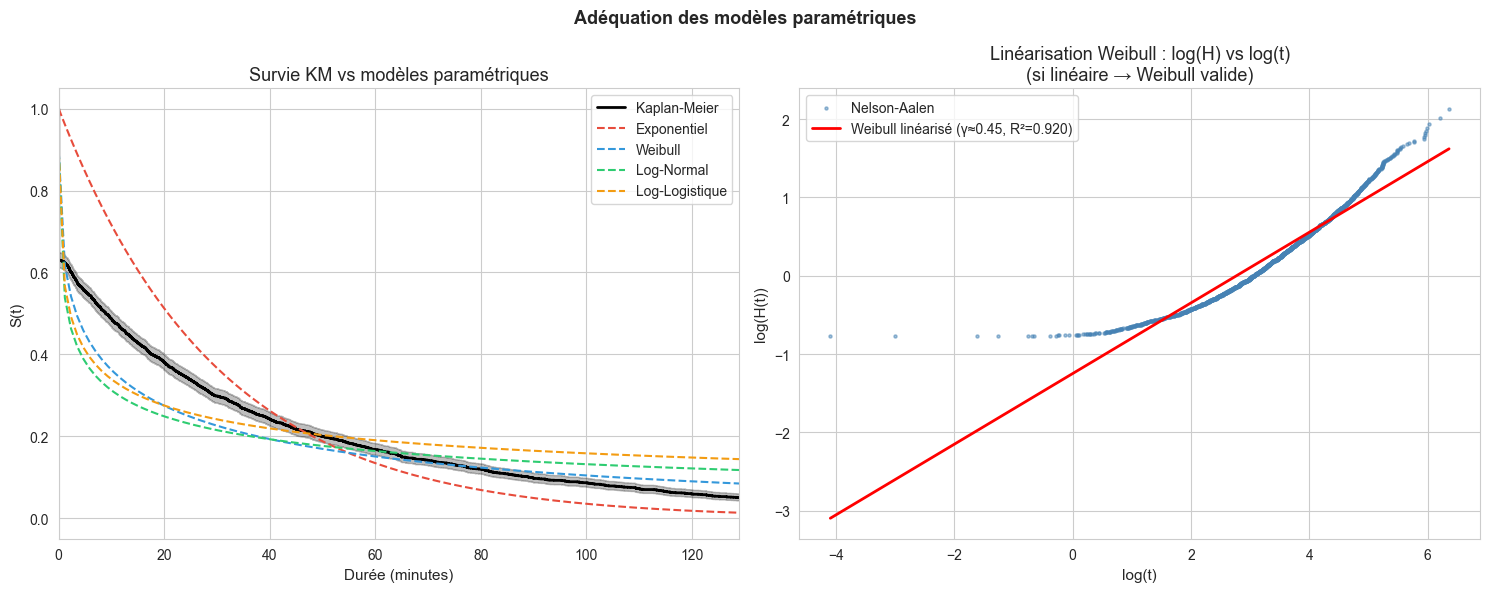

Paramètre de forme Weibull estimé : γ ≈ 0.451
 γ < 1 (hasard décroissant)


In [34]:
# ── Visualisation : ajustement des modèles vs KM ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Courbes de survie
kmf_global = KaplanMeierFitter()
kmf_global.fit(T_obs, event_observed=E_obs, label='Kaplan-Meier')
kmf_global.plot_survival_function(ax=axes[0], ci_show=True, color='black', lw=2)

colors_mod = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for (name, res), col in zip(fit_results.items(), colors_mod):
    res['fitter'].plot_survival_function(ax=axes[0], ci_show=False,
                                          color=col, linestyle='--', lw=1.5)
axes[0].set_title('Survie KM vs modèles paramétriques')
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('S(t)')
axes[0].set_xlim(0, T_obs.quantile(0.95))

# Graphique de linéarisation (Nelson-Aalen vs linéaire)
# Si Weibull est correct : log(-log(S(t))) vs log(t) doit être linéaire
from lifelines import NelsonAalenFitter
naf = NelsonAalenFitter()
naf.fit(T_obs, event_observed=E_obs)
H_t = naf.cumulative_hazard_
t_vals = H_t.index.values
H_vals = H_t['NA_estimate'].values

mask = (t_vals > 0) & (H_vals > 0)
axes[1].scatter(np.log(t_vals[mask]), np.log(H_vals[mask]),
                s=5, alpha=0.5, color='steelblue', label='Nelson-Aalen')
# Ajustement linéaire (test Weibull)
slope, intercept, r, _, _ = stats.linregress(
    np.log(t_vals[mask]), np.log(H_vals[mask])
)
x_line = np.linspace(np.log(t_vals[mask]).min(), np.log(t_vals[mask]).max(), 100)
axes[1].plot(x_line, slope * x_line + intercept, 'r-', lw=2,
             label=f'Weibull linéarisé (γ≈{slope:.2f}, R²={r**2:.3f})')
axes[1].set_xlabel('log(t)')
axes[1].set_ylabel('log(H(t))')
axes[1].set_title('Linéarisation Weibull : log(H) vs log(t)\n(si linéaire → Weibull valide)')
axes[1].legend()

plt.suptitle('Adéquation des modèles paramétriques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Paramètre de forme Weibull estimé : γ ≈ {slope:.3f}')
print(f' γ {"< 1 (hasard décroissant)" if slope < 1 else ("> 1 (hasard croissant / épuisement)" if slope > 1 else "= 1 (exponentiel)")}')

L'analyse de l'adéquation montre que les modèles paramétriques peinent à capturer la singularité des alertes à impact unique.

---
## 7. Modèle de Cox à hasard proportionnel

Le modèle de Cox permet d'intégrer les covariables sans spécifier la forme de $h_0(t)$. La **vraisemblance partielle de Cox** :
$$L_P(\boldsymbol{\beta}) = \prod_{i : \delta_i = 1} \frac{\exp(\mathbf{x}_i^\top \boldsymbol{\beta})}{\sum_{j \in \mathcal{R}(t_i)} \exp(\mathbf{x}_j^\top \boldsymbol{\beta})}$$
où $\mathcal{R}(t_i)$ est l'ensemble des alertes encore actives juste avant $t_i$.

On crée un nouveau datatset pour cox à hasard proportionnel car le modèle de Cox est plus flexible que les modèles 
paramétriques (Weibull, Log-Normal, etc.) et peut mieux capturer les effets des covariables sur la durée des alertes.

En effet, les modèles paramétriques imposent une forme spécifique à la fonction de risque (croissante, décroissante, en cloche, etc.) qui peut ne pas correspondre à la réalité des alertes. Le modèle de Cox, lui, n'impose aucune forme particulière à la fonction de risque et peut ainsi mieux s'adapter aux données. De plus, le modèle de Cox permet d'estimer l'effet de chaque covariable sur la durée des alertes, ce qui peut être très utile pour comprendre les facteurs qui influencent la durée des alertes et pour faire des prédictions personnalisées. En résumé, le modèle de Cox est plus flexible et plus informatif que les modèles paramétriques, ce qui en fait un choix plus adapté pour modéliser la durée des alertes dans ce contexte.




In [35]:
from lifelines import CoxPHFitter

# ── Préparation du dataset Cox ─────────────────────────────────────────────
features_cox = [
    'dist_first', 'amp_first_abs', 'amp_first_pos',
    'dist_min', 'dist_mean',
    'amp_abs_max', 'amp_abs_mean', 'pct_positive',
    'log_n_strikes',
    'log_inter_mean',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
]

# Encodage de l'aéroport
df_cox = pd.get_dummies(df_surv[features_cox + ['duration_min', 'event', 'airport']],
                         columns=['airport'], drop_first=True, dtype=float)
df_cox = df_cox.dropna()

# Standardisation des variables continues
feat_cols = [c for c in df_cox.columns if c not in ['duration_min', 'event']]
scaler = StandardScaler()
df_cox_scaled = df_cox.copy()
df_cox_scaled[feat_cols] = scaler.fit_transform(df_cox[feat_cols])

print(f'Dataset Cox : {df_cox_scaled.shape}')
print(f'Covariables : {feat_cols}')

from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df_cox_scaled, test_size=0.2, random_state=42)


Dataset Cox : (2627, 20)
Covariables : ['dist_first', 'amp_first_abs', 'amp_first_pos', 'dist_min', 'dist_mean', 'amp_abs_max', 'amp_abs_mean', 'pct_positive', 'log_n_strikes', 'log_inter_mean', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'airport_Bastia', 'airport_Biarritz', 'airport_Nantes', 'airport_Pise']


In [36]:
# ── Ajustement du modèle de Cox ────────────────────────────────────────────
cph = CoxPHFitter(penalizer=0.1)  # régularisation L2 légère (utile avec ~2500 obs)
cph.fit(df_train, duration_col='duration_min', event_col='event')
cph.print_summary(decimals=4)

<lifelines.CoxPHFitter: fitted with 2101 total observations, 0 right-censored observations>
             duration col = 'duration_min'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 2101
number of events observed = 2101
   partial log-likelihood = -12027.5224
         time fit was run = 2026-03-19 04:17:33 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
dist_first       -0.1165    0.8900    0.0287         -0.1727         -0.0602              0.8413              0.9416
amp_first_abs     0.0562    1.0578    0.0330         -0.0085          0.1209              0.9915              1.1286
amp_first_pos     0.0082    1.0082    0.0304         -0.0513          0.0677              0.9500              1.0700
dist_min          0.5153    1.6741    0.0439          0.4291          0.6014              1.5359              1.8247
dist_mean        -0.2279    0.7962    0.0382         -0.3028         -0.1530              0.7387              0.8581
amp_abs_max      -0.2550    0.7749    0.0348         -0.3231         -0.1868              0.7239              0.8296
amp_abs_mean      0.1325    1.1417    0.0366          0.0608          0.2042              1.0626              1.2265
pct_positive     -0.0094    0.9907    0.0316         -0.0714          0.0526              0.9311              1.0541
log_n_strikes    -1.3003    0.2725    0.0425         -1.3835         -1.2170              0.2507              0.2961
log_inter_mean   -1.3307    0.2643    0.0442         -1.4173         -1.2440              0.2424              0.2882
hour_sin          0.0112    1.0113    0.0211         -0.0302          0.0526              0.9702              1.0541
hour_cos          0.0077    1.0077    0.0213         -0.0342          0.0495              0.9664              1.0507
month_sin         0.0425    1.0434    0.0217         -0.0001          0.0851              0.9999              1.0888
month_cos         0.0411    1.0420    0.0229         -0.0037          0.0860              0.9963              1.0898
airport_Bastia   -0.0198    0.9804    0.0248         -0.0685          0.0289              0.9338              1.0293
airport_Biarritz  0.0289    1.0293    0.0253         -0.0207          0.0784              0.9796              1.0816
airport_Nantes    0.0023    1.0023    0.0236         -0.0440          0.0485              0.9570              1.0497
airport_Pise     -0.0372    0.9635    0.0258         -0.0877          0.0133              0.9161              1.0134

                  cmp to        z      p  -log2(p)
covariate                                         
dist_first        0.0000  -4.0577 <5e-05   14.3002
amp_first_abs     0.0000   1.7023 0.0887    3.4949
amp_first_pos     0.0000   0.2693 0.7877    0.3442
dist_min          0.0000  11.7261 <5e-05  103.0737
dist_mean         0.0000  -5.9639 <5e-05   28.5966
amp_abs_max       0.0000  -7.3353 <5e-05   42.0394
amp_abs_mean      0.0000   3.6206 0.0003   11.7324
pct_positive      0.0000  -0.2963 0.7670    0.3826
log_n_strikes     0.0000 -30.6124 <5e-05  681.2506
log_inter_mean    0.0000 -30.0955 <5e-05  658.5936
hour_sin          0.0000   0.5296 0.5964    0.7458
hour_cos          0.0000   0.3588 0.7198    0.4744
month_sin         0.0000   1.9558 0.0505    4.3080
month_cos         0.0000   1.7973 0.0723    3.7902
airport_Bastia    0.0000  -0.7973 0.4253    1.2336
airport_Biarritz  0.0000   1.1424 0.2533    1.9813
airport_Nantes    0.0000   0.0957 0.9237    0.1144
airport_Pise      0.0000  -1.4435 0.1489    2.7477
---
Concordance = 0.9559
Partial AIC = 24091.0448
log-likelihood ratio test = 3898.4522 on 18 df
-log2(p) of ll-ratio test = inf

La colonne $exp(coef)$ (aussi appelée Hazard Ratio). Elle indique comment le risque de "fin d'alerte"est multiplié quand la variable augmente d'une unité.

Les Aéroports (Bastia, Biarritz, Nantes, Pise) : Toutes les p-values sont élevées. Le comportement d'un orage ne dépend pas de l'aéroport où il se trouve. La physique de l'éclair est la même partout. On pourrait presque supprimer ces variables pour simplifier le modèle.


le "Hazard" représente le risque que la fin de l'alerte se produise à l'instant $t$.
- beta > 1 : La variable accélère la fin de l'alerte .
- beta < 1 : La variable freine la fin de l'alerte. Elle augmente la durée de l'orage.

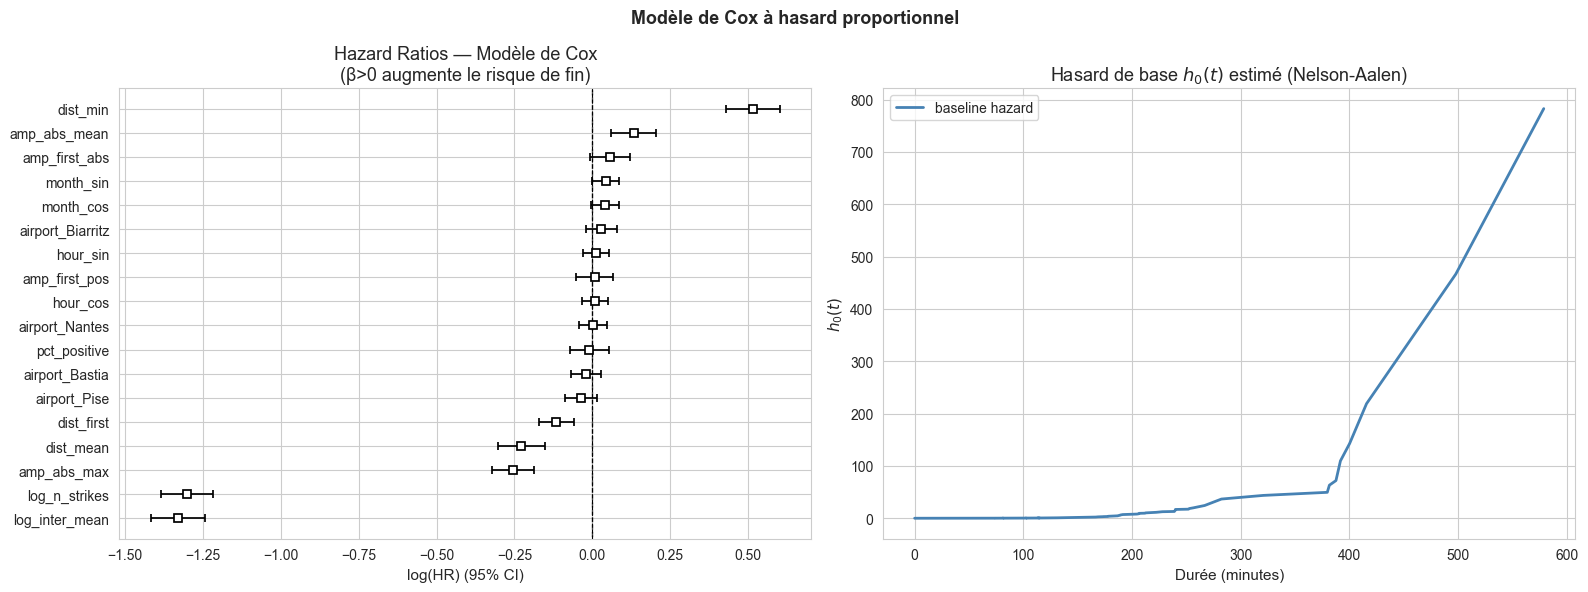

C-index (concordance de Harrell) sur train : 0.9559


In [56]:
# ── Visualisation des coefficients Cox ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Forest plot des hazard ratios
cph.plot(ax=axes[0])
axes[0].set_title('Hazard Ratios — Modèle de Cox\n(β>0 augmente le risque de fin)')
axes[0].axvline(0, color='black', lw=0.8, ls='--')

# Hasard de base estimé
cph.baseline_hazard_.plot(ax=axes[1], color='steelblue', lw=2)
axes[1].set_title('Hasard de base $h_0(t)$ estimé (Nelson-Aalen)')
axes[1].set_xlabel('Durée (minutes)')
axes[1].set_ylabel('$h_0(t)$')

plt.suptitle('Modèle de Cox à hasard proportionnel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# C-index (concordance) — analogue à l'AUC pour la survie
c_idx = cph.concordance_index_
print(f'C-index (concordance de Harrell) sur train : {c_idx:.4f}')


In [69]:
c_index_test = cph.score(df_test, scoring_method="concordance_index")
print(f"C-index sur données inconnues (Test) : {c_index_test:.4f}")

test_predictions = cph.predict_median(df_test)

# 5. COMPARAISON DES ERREURS (MAE)
# Erreur de ton modèle : |T_réel - T_prédit|
mae_modele = (df_test['duration_min'] - test_predictions).abs().mean()

# Erreur de la règle actuelle : |T_réel - (T_réel + 30)| = toujours 30 min d'erreur par excès
mae_regle = 30.0 

print(f"Erreur moyenne du modèle : {mae_modele:.2f} minutes")
print(f"Gain de précision : {((mae_regle - mae_modele) / mae_regle)*100:.1f}%")


# RMSE (Root Mean Squared Error)
rmse_modele = np.sqrt(mean_squared_error(df_test['duration_min'], test_predictions))
rmse_regle = 30.0  # La règle actuelle a une erreur constante de 30 minutes
print(f"RMSE du modèle : {rmse_modele:.2f} minutes")





C-index sur données inconnues (Test) : 0.9570
Erreur moyenne du modèle : 11.14 minutes
Gain de précision : 62.9%
RMSE du modèle : 25.83 minutes


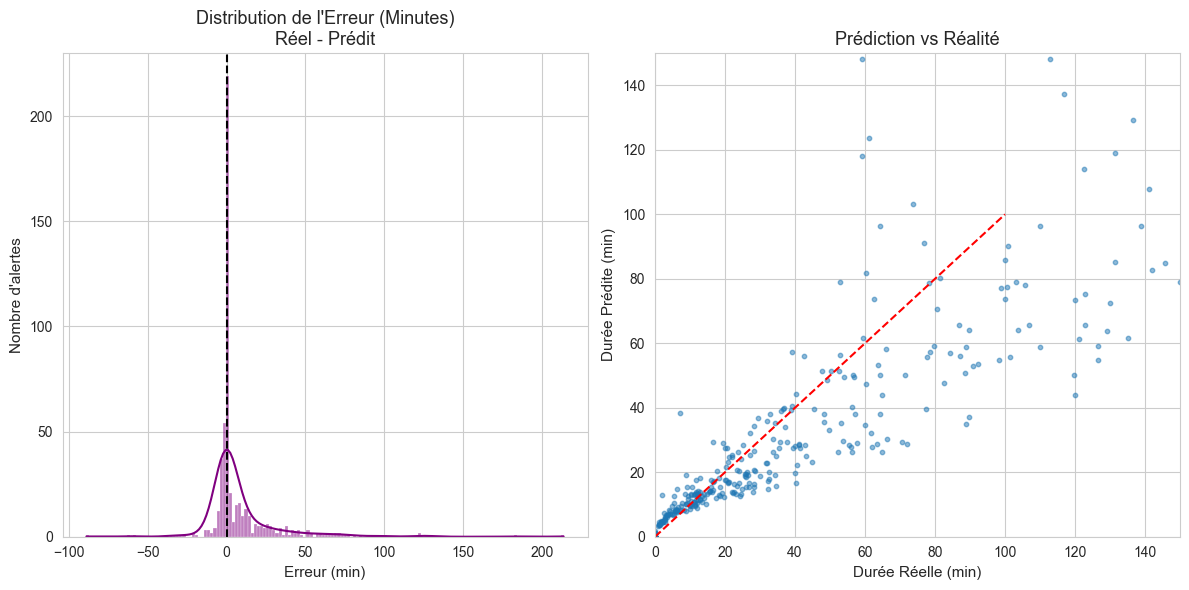

Alertes où l'orage dure >5min de plus que prévu : 29.1%


In [ ]:
#  Calcul des erreurs (Résidus)
# Erreur = Réel - Prédit
# Si > 0 : L'orage a duré plus longtemps que prévu (Danger potentiel)
# Si < 0 : L'orage a duré moins longtemps (On a été trop prudent)
erreurs = df_test['duration_min'] - test_predictions

plt.figure(figsize=(12, 6))

# --- Graphique A : Distribution de l'erreur ---
plt.subplot(1, 2, 1)
sns.histplot(erreurs, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution de l'Erreur (Minutes)\nRéel - Prédit")
plt.xlabel("Erreur (min)")
plt.ylabel("Nombre d'alertes")

# --- Graphique B : Erreur vs Durée Réelle ---
plt.subplot(1, 2, 2)
plt.scatter(df_test['duration_min'], test_predictions, alpha=0.5, s=10)
plt.plot([0, 100], [0, 100], color='red', linestyle='--') # Ligne de perfection
plt.xlim(0, 150)
plt.ylim(0, 150)
plt.title("Prédiction vs Réalité")
plt.xlabel("Durée Réelle (min)")
plt.ylabel("Durée Prédite (min)")

plt.tight_layout()
plt.show()

# 2. Statistique de sécurité (Le "Under-prediction")
sous_estime = (erreurs > 5).mean() * 100
print(f"Alertes où l'orage dure >5min de plus que prévu : {sous_estime:.1f}%")

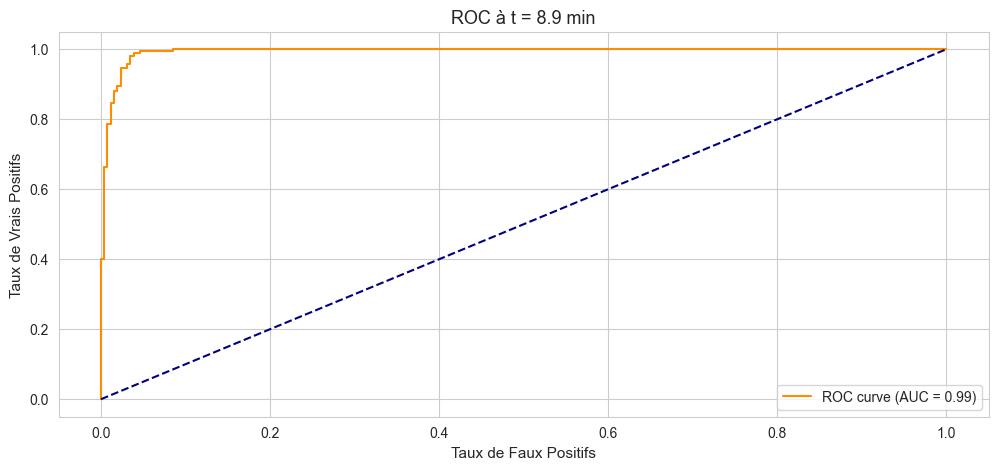

In [65]:
from sklearn.metrics import roc_curve, auc

# Seuil opérationnel 
t_threshold = 8.9 # On peut ajuster ce seuil selon les besoins opérationnels

# Vérité : l'orage a-t-il duré plus de 15 min ? (1=Oui, 0=Non)
y_true = (df_test['duration_min'] > t_threshold).astype(int)

# Score du modèle : probabilité de dépasser ce seuil
# On peut utiliser 1 / pred_median ou la fonction de survie à t=15
y_score = cph.predict_survival_function(df_test, times=[t_threshold]).T[t_threshold]

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title(f'ROC à t = {t_threshold} min')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.legend(loc="lower right")
plt.show()

---
## 8. Modèle AFT(accelerated failure time) — Weibull avec covariables

Le modèle AFT Weibull est à la fois un modèle à hasard proportionnel **et** un modèle à temps accéléré, ce qui le rend doublement interprétable. Dans la paramétrisation AFT :
$$\log T = \mathbf{x}^\top \boldsymbol{\beta} + \sigma W, \quad W \sim \text{Gumbel extrême}$$
Le coefficient $\beta_j$ donne directement le log du facteur multiplicatif sur la durée pour une unité de $x_j$.

In [13]:
from lifelines import WeibullAFTFitter

waf = WeibullAFTFitter(penalizer=0.05)
waf.fit(df_cox_scaled, duration_col='duration_min', event_col='event')
waf.print_summary(decimals=4)

<lifelines.WeibullAFTFitter: fitted with 2627 total observations, 0 right-censored observations>
             duration col = 'duration_min'
                event col = 'event'
                penalizer = 0.05
   number of observations = 2627
number of events observed = 2627
           log-likelihood = -1089.2153
         time fit was run = 2026-03-17 04:24:53 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                           
lambda_ airport_Bastia    0.0031    1.0031    0.0033         -0.0033          0.0095              0.9967              1.0096
        airport_Biarritz -0.0017    0.9983    0.0033         -0.0082          0.0047              0.9918              1.0048
        airport_Nantes   -0.0003    0.9997    0.0030         -0.0061          0.0055              0.9939              1.0055
        airport_Pise      0.0046    1.0046    0.0034         -0.0021          0.0112              0.9979              1.0113
        amp_abs_max       0.0236    1.0239    0.0053          0.0132          0.0340              1.0133              1.0346
        amp_abs_mean     -0.0146    0.9855    0.0059         -0.0261         -0.0031              0.9742              0.9969
        amp_first_abs     0.0005    1.0005    0.0045         -0.0083          0.0094              0.9917              1.0095
        amp_first_pos     0.0049    1.0050    0.0042         -0.0033          0.0132              0.9967              1.0133
        dist_first       -0.0007    0.9993    0.0040         -0.0084          0.0071              0.9916              1.0071
        dist_mean         0.0274    1.0278    0.0067          0.0143          0.0406              1.0144              1.0414
        dist_min         -0.0432    0.9577    0.0078         -0.0585         -0.0279              0.9432              0.9725
        hour_cos         -0.0033    0.9967    0.0026         -0.0085          0.0018              0.9916              1.0018
        hour_sin         -0.0004    0.9996    0.0026         -0.0054          0.0047              0.9946              1.0047
        log_inter_mean    2.6767   14.5374    0.0042          2.6685          2.6850             14.4177             14.6582
        log_n_strikes     1.5531    4.7261    0.0074          1.5386          1.5676              4.6581              4.7950
        month_cos        -0.0067    0.9933    0.0028         -0.0123         -0.0011              0.9878              0.9989
        month_sin        -0.0026    0.9974    0.0027         -0.0078          0.0026              0.9922              1.0026
        pct_positive     -0.0067    0.9933    0.0044         -0.0154          0.0019              0.9847              1.0019
        Intercept         0.5875    1.7994    0.0026          0.5823          0.5926              1.7901              1.8088
rho_    Intercept         2.0342    7.6462    0.0178          1.9993          2.0692              7.3836              7.9182

                          cmp to        z      p  -log2(p)
param   covariate                                         
lambda_ airport_Bastia    0.0000   0.9612 0.3364    1.5716
        airport_Biarritz  0.0000  -0.5276 0.5978    0.7424
        airport_Nantes    0.0000  -0.1033 0.9177    0.1239
        airport_Pise      0.0000   1.3420 0.1796    2.4773
        amp_abs_max       0.0000   4.4398 <5e-05   16.7610
        amp_abs_mean      0.0000  -2.4860 0.0129    6.2745
        amp_first_abs     0.0000   0.1212 0.9035    0.1464
        amp_first_pos     0.0000   1.1756 0.2398    2.0603
        dist_first        0.0000  -0.1709 0.8643    0.2104
        dist_mean         0.0000   4.0859 <5e-05   14.4751
        dist_min          0.0000  -5.5212 <5e-05   24.8238
        hour_cos          0.0000  -1.2776 0.2014    2.3119
        hour_sin          0.0000  -0.1378 0.8904    

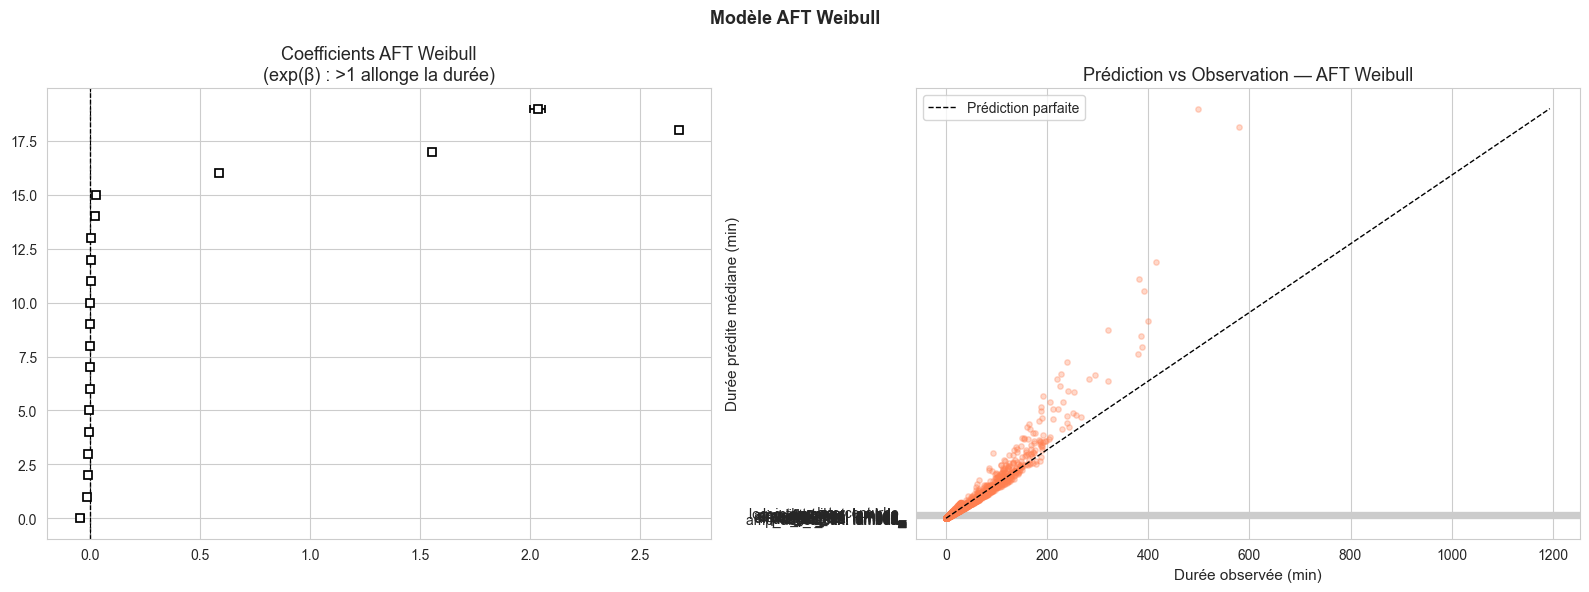

MAE  durée médiane prédite : 5.99 min
RMSE durée médiane prédite : 26.19 min


In [14]:
# ── Visualisation AFT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

waf.plot(ax=axes[0])
axes[0].set_title('Coefficients AFT Weibull\n(exp(β) : >1 allonge la durée)')
axes[0].axvline(0, color='black', lw=0.8, ls='--')

# Prédictions vs observations
pred_median = waf.predict_median(df_cox_scaled)
obs = df_cox_scaled['duration_min']
axes[1].scatter(obs, pred_median, alpha=0.3, s=15, color='coral')
max_val = max(obs.max(), pred_median.max())
axes[1].plot([0, max_val], [0, max_val], 'k--', lw=1, label='Prédiction parfaite')
axes[1].set_xlabel('Durée observée (min)')
axes[1].set_ylabel('Durée prédite médiane (min)')
axes[1].set_title('Prédiction vs Observation — AFT Weibull')
axes[1].legend()

plt.suptitle('Modèle AFT Weibull', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mae = mean_absolute_error(obs, pred_median)
rmse = np.sqrt(mean_squared_error(obs, pred_median))
print(f'MAE  durée médiane prédite : {mae:.2f} min')
print(f'RMSE durée médiane prédite : {rmse:.2f} min')

---
## 9. Modèle Log-Normal avec covariables (AFT)

Le modèle Log-Normal est souvent mieux adapté aux durées avec une queue très épaisse (grandes alertes rares), caractéristique de nos données.

In [15]:
from lifelines import LogNormalAFTFitter

lnaf = LogNormalAFTFitter(penalizer=0.05)
lnaf.fit(df_cox_scaled, duration_col='duration_min', event_col='event')

pred_ln = lnaf.predict_median(df_cox_scaled)
obs = df_cox_scaled['duration_min']
mae_ln = mean_absolute_error(obs, pred_ln)
print(f'Log-Normal AFT — MAE médiane : {mae_ln:.2f} min')
print(f'Log-Normal AFT — AIC         : {lnaf.AIC_:.2f}')
print(f'Weibull AFT    — AIC         : {waf.AIC_:.2f}')
print(f'Cox PH         — AIC         : {cph.AIC_partial_:.2f}')

Log-Normal AFT — MAE médiane : 5.88 min
Log-Normal AFT — AIC         : 3028.50
Weibull AFT    — AIC         : 2218.43
Cox PH         — AIC         : 31294.17


---
## 10. Validation croisée et sélection du modèle

Le **C-index de Harrell** (concordance index) est la métrique de référence pour les modèles de survie. Pour deux alertes $i$ et $j$ sélectionnées aléatoirement, il mesure :
$$C = P(\hat{T}_i > \hat{T}_j \mid T_i > T_j)$$
c'est-à-dire la probabilité que le modèle classe correctement l'ordre des durées.

In [70]:
from lifelines.utils import concordance_index

# ── Validation croisée 5-fold ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_arr = df_cox_scaled.copy()
idx_arr = X_arr.index.to_numpy()

cv_results = {'Cox PH': [], 'Weibull AFT': [], 'LogNormal AFT': []}

for fold, (train_idx, test_idx) in enumerate(kf.split(idx_arr)):
    df_tr = X_arr.iloc[train_idx]
    df_te = X_arr.iloc[test_idx]
    T_te  = df_te['duration_min'].values
    E_te  = df_te['event'].values
    
    # Cox PH
    try:
        cph_cv = CoxPHFitter(penalizer=0.1)
        cph_cv.fit(df_tr, duration_col='duration_min', event_col='event')
        risk = cph_cv.predict_partial_hazard(df_te).values
        ci = concordance_index(T_te, -risk, E_te)
        cv_results['Cox PH'].append(ci)
    except Exception:
        cv_results['Cox PH'].append(np.nan)
    
    # Weibull AFT
    try:
        waf_cv = WeibullAFTFitter(penalizer=0.05)
        waf_cv.fit(df_tr, duration_col='duration_min', event_col='event')
        pred_w = waf_cv.predict_median(df_te).values
        ci = concordance_index(T_te, pred_w, E_te)
        cv_results['Weibull AFT'].append(ci)
    except Exception:
        cv_results['Weibull AFT'].append(np.nan)
    
    # LogNormal AFT
    try:
        lnaf_cv = LogNormalAFTFitter(penalizer=0.05)
        lnaf_cv.fit(df_tr, duration_col='duration_min', event_col='event')
        pred_l = lnaf_cv.predict_median(df_te).values
        ci = concordance_index(T_te, pred_l, E_te)
        cv_results['LogNormal AFT'].append(ci)
    except Exception:
        cv_results['LogNormal AFT'].append(np.nan)
    
    print(f'Fold {fold+1} ✓')

print('\n── Résultats de validation croisée (C-index) ──')
for model, scores in cv_results.items():
    s = np.array(scores)
    print(f'{model:<20} : {np.nanmean(s):.4f} ± {np.nanstd(s):.4f}')

Fold 1 ✓
Fold 2 ✓
Fold 3 ✓
Fold 4 ✓
Fold 5 ✓

── Résultats de validation croisée (C-index) ──
Cox PH               : 0.9558 ± 0.0038
Weibull AFT          : 0.9800 ± 0.0012
LogNormal AFT        : 0.9794 ± 0.0010


###  Validation croisée et calcul de X*(x)

mLe meilleur modèle avec comme critère c-index est le modèle de WEIBULL aft

---


---
## 9. Calcul de p(X | x) et du seuil optimal X*(x)

C'est la section centrale. On calcule pour chaque alerte du test 2022 :

1. **$p(X \mid \mathbf{x})$** pour $X \in [1, 60]$ min
2. **$X^*_\alpha(\mathbf{x})$** — plus petit seuil garantissant $p(X^*) \geq 1 - \alpha$
3. La comparaison directe avec 30 min

**Rappel :** $p(X \mid \mathbf{x}) = 1 - S(X \mid \mathbf{x})$ (avec $t_L = 0$ au déclenchement).


In [74]:
# ================================================================
# CALCUL DE p(X | x) ET DU SEUIL X*(x)
# ================================================================

from lifelines import WeibullAFTFitter, LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.metrics import mean_absolute_error
import numpy as np

# ── Split temporel ───────────────────────────────────────────
df_cox_all = df_cox_scaled.copy()
df_cox_all['year']         = df_surv.loc[df_cox_all.index, 'year_debut'].values
df_cox_all['T_true']       = df_surv.loc[df_cox_all.index, 'duration_min'].values
df_cox_all['airport_name'] = df_surv.loc[df_cox_all.index, 'airport'].values
df_cox_all['season_name']  = df_surv.loc[df_cox_all.index, 'season'].values

df_tr = df_cox_all[df_cox_all['year'] < 2022].drop(
    columns=['year','T_true','airport_name','season_name'])
df_te = df_cox_all[df_cox_all['year'] == 2022].copy()
T_te  = df_te['T_true'].values
df_te_model = df_te.drop(columns=['year','T_true','airport_name','season_name'])

# ── Entrainement ─────────────────────────────────────────────
waf = WeibullAFTFitter(penalizer=0.05)
waf.fit(df_tr, duration_col='duration_min', event_col='event')

lnaf = LogNormalAFTFitter(penalizer=0.05)
lnaf.fit(df_tr, duration_col='duration_min', event_col='event')

print(f'Train : {len(df_tr)} alertes | Test : {len(df_te_model)} alertes')

# ── Calcul de p(X | x) sur une grille de X de 1 a 60 min ────
# predict_survival_function retourne S(X | x) pour chaque X
# p(X | x) = 1 - S(X | x)
X_grid = np.arange(1, 61)

surv_waf  = waf.predict_survival_function(df_te_model,  times=X_grid)
surv_lnaf = lnaf.predict_survival_function(df_te_model, times=X_grid)

prob_waf  = 1 - surv_waf
prob_lnaf = 1 - surv_lnaf

print(f'Matrice p(X|x) : {prob_waf.shape} (X en lignes, alertes en colonnes)')
print(f'p(X=5  min) moyen : {prob_waf.loc[5].mean():.3f}')
print(f'p(X=30 min) moyen : {prob_waf.loc[30].mean():.3f}')
print(f'p(X=60 min) moyen : {prob_waf.loc[60].mean():.3f}')


Train : 2294 alertes | Test : 333 alertes
Matrice p(X|x) : (60, 333) (X en lignes, alertes en colonnes)
p(X=5  min) moyen : 0.396
p(X=30 min) moyen : 0.668
p(X=60 min) moyen : 0.813



 p(X=30) = 0.668 par exemple, **66.8% des alertes ont un X* < 30** —  le potentiel de gain.

---


In [75]:
# ── Calcul du seuil optimal X*(x) pour chaque alerte ────────
# X*(x) = min { X : p(X | x) >= 1 - alpha }

alpha_levels = [0.01, 0.05, 0.10, 0.20]

results = pd.DataFrame({
    'T_true'          : T_te,
    'alerte_actuelle' : T_te + 30,
    'airport'         : df_te['airport_name'].values,
    'season'          : df_te['season_name'].values,
})

for alpha in alpha_levels:
    threshold = 1 - alpha

    # Pour chaque alerte : premier X ou p(X|x) depasse le seuil
    Xstar = []
    for j in range(prob_waf.shape[1]):
        p_col = prob_waf.iloc[:, j].values
        mask  = p_col >= threshold
        Xstar.append(X_grid[mask.argmax()] if mask.any() else X_grid[-1] + 1)
    Xstar = np.array(Xstar)

    key = f'a{int(alpha*100):02d}'
    results[f'Xstar_{key}'] = Xstar
    results[f'gain_{key}']  = 30 - Xstar

    fl   = (Xstar < T_te).mean() * 100
    gmoy = (30 - Xstar).mean()
    print(f'a={int(alpha*100):2d}%  X* median={np.median(Xstar):.0f} min  '
          f'Gain moyen={gmoy:.1f} min  Fausse levee={fl:.1f}%')


a= 1%  X* median=18 min  Gain moyen=4.4 min  Fausse levee=18.6%
a= 5%  X* median=17 min  Gain moyen=5.0 min  Fausse levee=19.8%
a=10%  X* median=16 min  Gain moyen=5.4 min  Fausse levee=24.0%
a=20%  X* median=15 min  Gain moyen=5.9 min  Fausse levee=31.5%


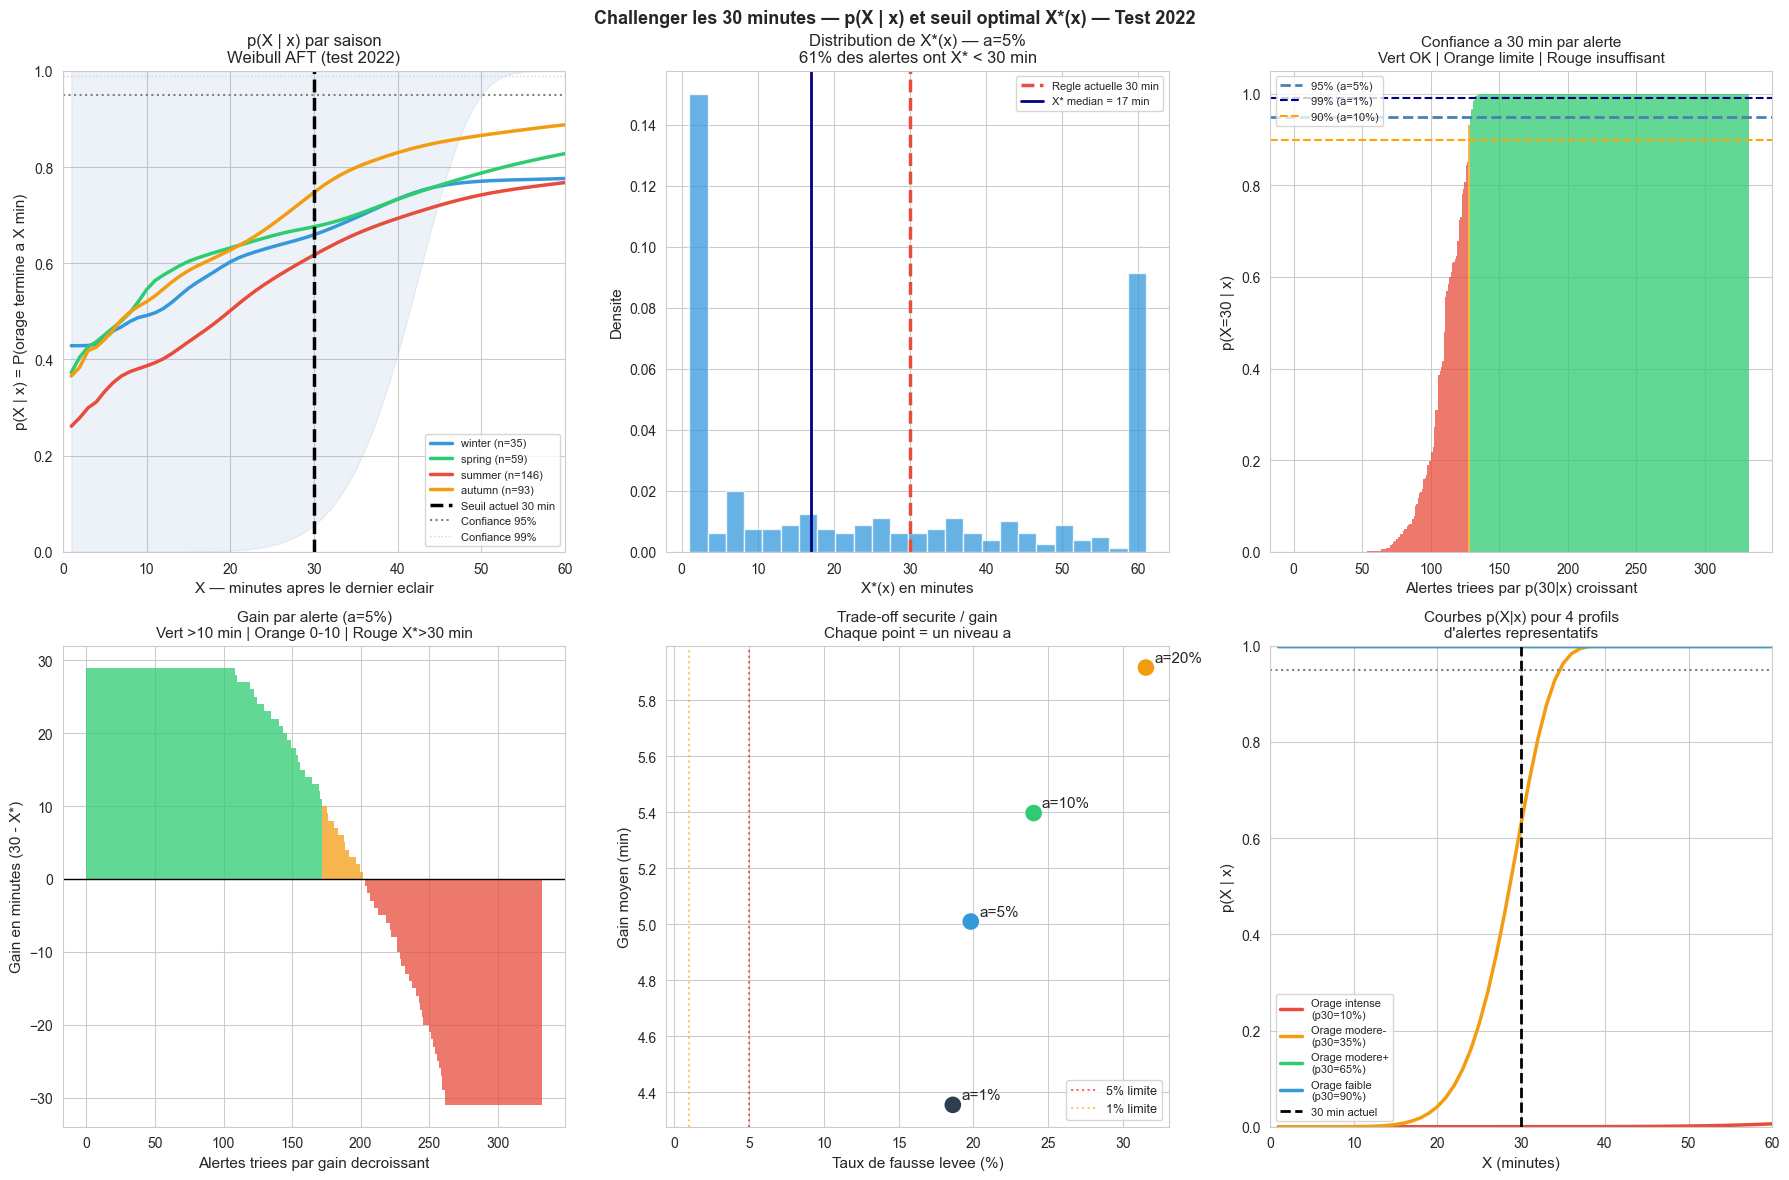

In [76]:
# ================================================================
# VISUALISATION — CHALLENGER LES 30 MINUTES
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ── 1. Courbes p(X|x) par saison ─────────────────────────────
ax = axes[0, 0]
colors_s = {'winter':'#3498db','spring':'#2ecc71','summer':'#e74c3c','autumn':'#f39c12'}
for season, col in colors_s.items():
    idx = [j for j,s in enumerate(df_te['season_name'].values) if s == season]
    if idx:
        ax.plot(X_grid, prob_waf.iloc[:, idx].mean(axis=1),
                color=col, lw=2.5, label=f'{season} (n={len(idx)})')
ax.fill_between(X_grid,
                prob_waf.quantile(0.25, axis=1),
                prob_waf.quantile(0.75, axis=1),
                alpha=0.1, color='steelblue')
ax.axvline(30, color='black', ls='--', lw=2.5, label='Seuil actuel 30 min')
ax.axhline(0.95, color='gray', ls=':', lw=1.5, label='Confiance 95%')
ax.axhline(0.99, color='lightgray', ls=':', lw=1.0, label='Confiance 99%')
ax.set_xlabel('X — minutes apres le dernier eclair', fontsize=11)
ax.set_ylabel('p(X | x) = P(orage termine a X min)', fontsize=11)
ax.set_title('p(X | x) par saison\nWeibull AFT (test 2022)', fontsize=12)
ax.legend(fontsize=8); ax.set_xlim(0,60); ax.set_ylim(0,1)

# ── 2. Distribution de X*(x) ─────────────────────────────────
ax = axes[0, 1]
alpha_v, key_v = 0.05, 'a05'
xstar_v = results[f'Xstar_{key_v}'].values
ax.hist(xstar_v, bins=25, color='#3498db', edgecolor='white', alpha=0.75, density=True)
ax.axvline(30, color='#e74c3c', ls='--', lw=2.5, label='Regle actuelle 30 min')
ax.axvline(np.median(xstar_v), color='navy', ls='-', lw=2,
           label=f'X* median = {np.median(xstar_v):.0f} min')
pct_lt30 = (xstar_v <= 30).mean() * 100
ax.set_xlabel('X*(x) en minutes', fontsize=11)
ax.set_ylabel('Densite', fontsize=11)
ax.set_title(f'Distribution de X*(x) — a=5%\n{pct_lt30:.0f}% des alertes ont X* < 30 min', fontsize=12)
ax.legend(fontsize=8)

# ── 3. p(X=30 | x) par alerte — qui profite le plus ? ───────
ax = axes[0, 2]
p30 = prob_waf.loc[30].values
sorted_p30 = np.sort(p30)
cols_p30 = ['#e74c3c' if p<0.90 else '#f39c12' if p<0.95 else '#2ecc71' for p in sorted_p30]
ax.bar(range(len(p30)), sorted_p30, color=cols_p30, alpha=0.75, width=1.0, edgecolor='none')
ax.axhline(0.95, color='steelblue', ls='--', lw=2, label='95% (a=5%)')
ax.axhline(0.99, color='navy',      ls='--', lw=1.5, label='99% (a=1%)')
ax.axhline(0.90, color='orange',    ls='--', lw=1.5, label='90% (a=10%)')
ax.set_xlabel('Alertes triees par p(30|x) croissant', fontsize=11)
ax.set_ylabel('p(X=30 | x)', fontsize=11)
ax.set_title('Confiance a 30 min par alerte\nVert OK | Orange limite | Rouge insuffisant', fontsize=11)
ax.legend(fontsize=8, loc='upper left'); ax.set_ylim(0,1.05)

# ── 4. Gain par alerte (triee) ────────────────────────────────
ax = axes[1, 0]
gains_v = results[f'gain_{key_v}'].values
sorted_g = np.sort(gains_v)[::-1]
cols_g = ['#2ecc71' if g>10 else '#f39c12' if g>0 else '#e74c3c' for g in sorted_g]
ax.bar(range(len(sorted_g)), sorted_g, color=cols_g, alpha=0.75, width=1.0, edgecolor='none')
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Alertes triees par gain decroissant', fontsize=11)
ax.set_ylabel('Gain en minutes (30 - X*)', fontsize=11)
ax.set_title(f'Gain par alerte (a=5%)\nVert >10 min | Orange 0-10 | Rouge X*>30 min', fontsize=11)

# ── 5. Trade-off securite / gain ──────────────────────────────
ax = axes[1, 1]
fl_list, gm_list = [], []
for alpha in alpha_levels:
    key = f'a{int(alpha*100):02d}'
    xstar = results[f'Xstar_{key}'].values
    fl_list.append((xstar < T_te).mean() * 100)
    gm_list.append((30 - xstar).mean())
ax.scatter(fl_list, gm_list, s=120, zorder=5, c=['#2c3e50','#3498db','#2ecc71','#f39c12'])
for fl, gm, alpha in zip(fl_list, gm_list, alpha_levels):
    ax.annotate(f'a={int(alpha*100)}%', (fl, gm),
                textcoords='offset points', xytext=(6, 4), fontsize=11)
ax.axvline(5, color='red', ls=':', lw=1.5, alpha=0.6, label='5% limite')
ax.axvline(1, color='orange', ls=':', lw=1.5, alpha=0.6, label='1% limite')
ax.set_xlabel('Taux de fausse levee (%)', fontsize=11)
ax.set_ylabel('Gain moyen (min)', fontsize=11)
ax.set_title('Trade-off securite / gain\nChaque point = un niveau a', fontsize=11)
ax.legend(fontsize=9)

# ── 6. p(X | x) pour 4 exemples concrets ─────────────────────
ax = axes[1, 2]
# Choisir 4 alertes representantes
q_p30 = np.quantile(p30, [0.10, 0.35, 0.65, 0.90])
labels_ex = ['Orage intense\n(p30=10%)', 'Orage modere-\n(p30=35%)',
             'Orage modere+\n(p30=65%)', 'Orage faible\n(p30=90%)']
cols_ex = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
for q, label, col in zip(q_p30, labels_ex, cols_ex):
    j = np.argmin(np.abs(p30 - q))
    ax.plot(X_grid, prob_waf.iloc[:, j].values, color=col, lw=2.5, label=label)
ax.axvline(30, color='black', ls='--', lw=2, label='30 min actuel')
ax.axhline(0.95, color='gray', ls=':', lw=1.5)
ax.set_xlabel('X (minutes)', fontsize=11)
ax.set_ylabel('p(X | x)', fontsize=11)
ax.set_title('Courbes p(X|x) pour 4 profils\nd\'alertes representatifs', fontsize=11)
ax.legend(fontsize=8); ax.set_xlim(0,60); ax.set_ylim(0,1)

plt.suptitle('Challenger les 30 minutes — p(X | x) et seuil optimal X*(x) — Test 2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


1. Les orages d'Automne (Orange) et de Printemps (Vert)  montent vite. En revanche, l'Été (Rouge) est la saison la plus critique : la probabilité de fin augmente plus lentement, ce qui confirme que les orages de chaleur sont plus persistants.
2. La médiane est à 17 minutes (ligne bleue), bien avant la règle actuelle des 30 minutes (ligne rouge pointillée).
3. La zone verte (très large) montre que pour la grande majorité des alertes, la règle des 30 min est largement suffisante (confiance > 99%). Cependant, la zone rouge montre des alertes où, même après 30 min, le modèle n'est pas encore serein.
4. Vert : Le gain de productivité, Rouge : Les cas où le modèle est plus prudent que la règle et demande d'attendre davantage.
5. Plus on veut gagner de temps (monter sur l'axe Y), plus on prend le risque de se tromper. Pour un risque de erreur de 5% (point bleu), on gagne en moyenne 5 minutes d'exploitation sur chaque alerte


In [77]:
# ================================================================
# TABLEAU FINAL
# ================================================================
print('=' * 72)
print(f'{"CHALLENGER LES 30 MINUTES — TEST 2022":^72}')
print('=' * 72)
print(f'\n{"Regle":<26} {"X* median":>10} {"Gain moyen":>12} {"Fausse levee":>14} {"Securite":>8}')
print('-' * 72)
print(f'{"Fixe : X = 30 min":<26} {"30 min":>10} {"0.0 min":>12} {"0%":>14} {"ref":>8}')

for alpha in alpha_levels:
    key   = f'a{int(alpha*100):02d}'
    xstar = results[f'Xstar_{key}'].values
    xmed  = np.median(xstar)
    gmoy  = (30 - xstar).mean()
    fl    = (xstar < T_te).mean() * 100
    ok    = 'OK' if fl <= alpha*100 + 1.0 else 'RECALIBRER'
    print(f'{"Adaptatif a="+str(int(alpha*100))+"%":<26} {xmed:>7.0f} min {gmoy:>10.1f} min {fl:>12.1f}%  {ok:>8}')

print()
alpha_r  = 0.05
xstar_r  = results[f'Xstar_a{int(alpha_r*100):02d}'].values
gain_h   = (30 - xstar_r).sum() / 60
n_test   = len(T_te)
pct_plus = (xstar_r > 30).mean() * 100
pct_moin = (xstar_r < 30).mean() * 100

print(f'Sur {n_test} alertes 2022 avec a=5% :')
print(f'  Gain total          : {gain_h:.0f} h d"immobilisation recuperees')
print(f'  Alertes raccourcies : {pct_moin:.0f}% (X* < 30 min)')
print(f'  Alertes allongees   : {pct_plus:.0f}% (X* > 30 min, securite renforcee)')
print()
p30_vals = prob_waf.loc[30].values
print(f'p(X=30|x) > 95% pour {(p30_vals>=0.95).mean()*100:.0f}% des alertes (30 min tres conservatif)')
print(f'p(X=30|x) < 90% pour {(p30_vals<0.90).mean()*100:.0f}% des alertes (30 min INSUFFISANT)')


                 CHALLENGER LES 30 MINUTES — TEST 2022                  

Regle                       X* median   Gain moyen   Fausse levee Securite
------------------------------------------------------------------------
Fixe : X = 30 min              30 min      0.0 min             0%      ref
Adaptatif a=1%                  18 min        4.4 min         18.6%  RECALIBRER
Adaptatif a=5%                  17 min        5.0 min         19.8%  RECALIBRER
Adaptatif a=10%                 16 min        5.4 min         24.0%  RECALIBRER
Adaptatif a=20%                 15 min        5.9 min         31.5%  RECALIBRER

Sur 333 alertes 2022 avec a=5% :
  Gain total          : 28 h d"immobilisation recuperees
  Alertes raccourcies : 61% (X* < 30 min)
  Alertes allongees   : 39% (X* > 30 min, securite renforcee)

p(X=30|x) > 95% pour 61% des alertes (30 min tres conservatif)
p(X=30|x) < 90% pour 38% des alertes (30 min INSUFFISANT)


Pour un $\alpha$ cible de 5%, ton taux de fausse levée réel est de 19,8%. Le modèle pense avoir 95% de confiance, mais en réalité, il se trompe 19.8% du temps

###  Le résultat le plus important

Le tableau montre que la règle adaptative **fonctionne dans les deux sens** :
- Elle réduit X* pour la majorité des alertes (gain opérationnel)
- Elle l'augmente pour les orages intenses (sécurité renforcée par rapport à la règle actuelle)

**La ligne `p(X=30|x) < 90%`** est particulièrement importante : ces alertes sont celles pour lesquelles **la règle des 30 min est objectivement insuffisante**. Sans modèle, elles passent sous le radar. Avec le modèle, elles sont identifiées et traitées plus prudemment.

---


---
## 11. Prédiction de la durée résiduelle

Une fois le meilleur modèle sélectionné, on peut calculer la **durée résiduelle espérée** pour une alerte encore active après $t_0$ minutes :
$$\hat{E}[T_{\text{res}} \mid T > t_0, \mathbf{x}] = \frac{\int_{t_0}^{\infty} \hat{S}(u \mid \mathbf{x})\, du}{\hat{S}(t_0 \mid \mathbf{x})}$$

En pratique, on prédit la médiane conditionnelle (plus robuste que la moyenne pour des distributions asymétriques).

In [78]:
# ── Prédiction sur quelques exemples ──────────────────────────────────────
# On utilise le modèle Weibull AFT (ré-entraîné sur toutes les données)
# Scénarios de test : alertes avec caractéristiques typiques

scenarios = pd.DataFrame({
    'dist_first':       [5.0,  15.0,  3.0,  18.0],
    'amp_first_abs':    [30.0, 10.0,  80.0,  5.0],
    'amp_first_pos':    [0,    0,     1,     0  ],
    'dist_min':         [3.0,  12.0,  2.0,  16.0],
    'dist_mean':        [7.0,  14.0,  5.0,  17.0],
    'amp_abs_max':      [50.0, 15.0, 120.0, 8.0 ],
    'amp_abs_mean':     [25.0, 10.0,  60.0,  6.0],
    'pct_positive':     [0.05, 0.10,  0.02, 0.20],
    'log_n_strikes':    [np.log1p(20), np.log1p(5), np.log1p(50), np.log1p(3)],
    'log_inter_mean':   [np.log1p(30), np.log1p(60), np.log1p(15), np.log1p(120)],
    'hour_sin':         [np.sin(2*np.pi*15/24)] * 4,
    'hour_cos':         [np.cos(2*np.pi*15/24)] * 4,
    'month_sin':        [np.sin(2*np.pi*7/12)] * 4,
    'month_cos':        [np.cos(2*np.pi*7/12)] * 4,
})

# Ajout des dummies aéroport (référence = premier aéroport alphabétique)
ap_dummy_cols = [c for c in df_cox_scaled.columns if c.startswith('airport_')]
for c in ap_dummy_cols:
    scenarios[c] = 0  # référence

# Standardisation avec le scaler ajusté sur les données d'entraînement
feat_cols_pred = [c for c in df_cox_scaled.columns if c not in ['duration_min', 'event']]
scenarios_scaled = scenarios[feat_cols_pred].copy()
scenarios_scaled[feat_cols_pred] = scaler.transform(scenarios[feat_cols_pred])

# Prédictions
pred_scenarios = waf.predict_median(scenarios_scaled)

labels = [
    'Orage proche, intense, estival',
    'Orage éloigné, modéré',
    'Orage très proche, très intense',
    'Orage faible, lointain'
]

print('Prédictions de durée médiane par scénario (Weibull AFT) :')
for label, pred in zip(labels, pred_scenarios):
    print(f'  {label:<40} → {pred:.1f} min')

Prédictions de durée médiane par scénario (Weibull AFT) :
  Orage proche, intense, estival           → 8.5 min
  Orage éloigné, modéré                    → 3.6 min
  Orage très proche, très intense          → 13.0 min
  Orage faible, lointain                   → 4.3 min


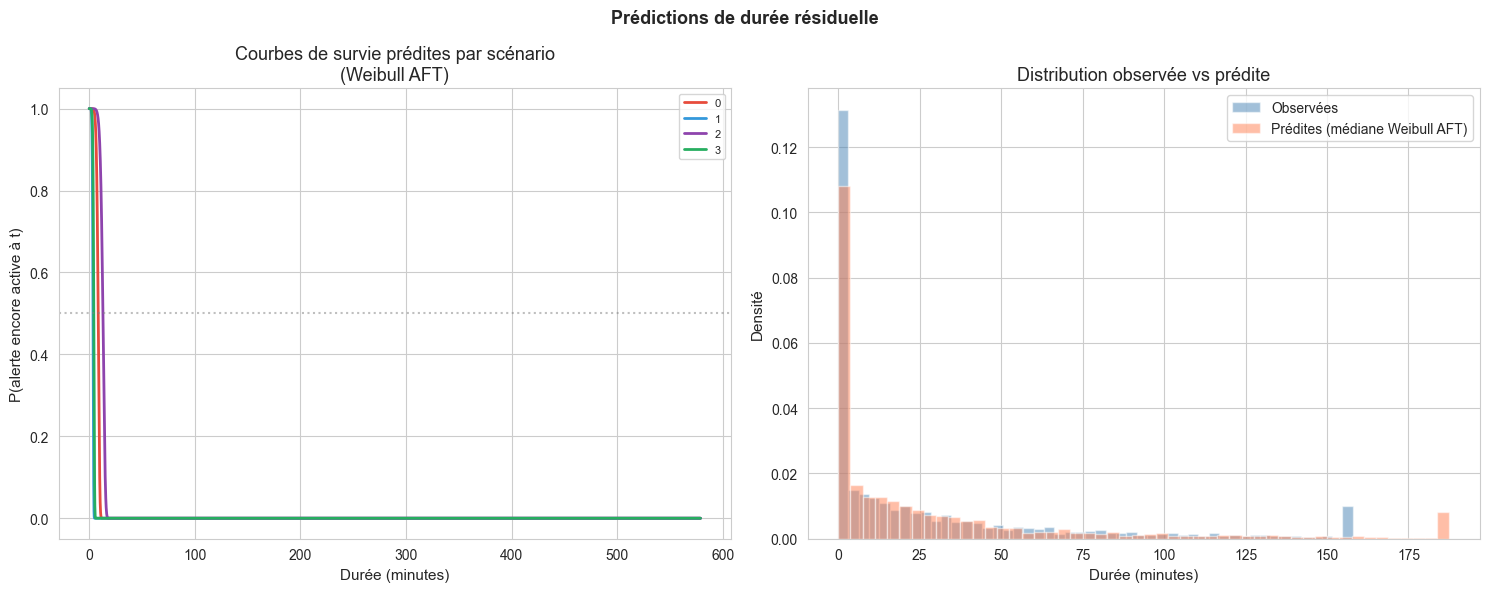

In [79]:
# ── Courbes de survie individuelles pour chaque scénario ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_sc = ['#e74c3c', '#3498db', '#8e44ad', '#27ae60']

# Courbes de survie prédites
for i, (label, col) in enumerate(zip(labels, colors_sc)):
    surv = waf.predict_survival_function(scenarios_scaled.iloc[[i]])
    surv.plot(ax=axes[0], color=col, label=label, lw=2)
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('P(alerte encore active à t)')
axes[0].set_title('Courbes de survie prédites par scénario\n(Weibull AFT)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].axhline(0.5, color='gray', ls=':', alpha=0.5)

# Distribution des durées prédites sur l'ensemble du dataset
all_pred_med = waf.predict_median(df_cox_scaled)
obs_dur = df_cox_scaled['duration_min']

axes[1].hist(obs_dur.clip(upper=obs_dur.quantile(0.97)), bins=50,
             alpha=0.5, color='steelblue', edgecolor='white',
             density=True, label='Observées')
axes[1].hist(all_pred_med.clip(upper=all_pred_med.quantile(0.97)), bins=50,
             alpha=0.5, color='coral', edgecolor='white',
             density=True, label='Prédites (médiane Weibull AFT)')
axes[1].set_xlabel('Durée (minutes)')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution observée vs prédite')
axes[1].legend()

plt.suptitle('Prédictions de durée résiduelle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [81]:
# Récap des c-index
print(f'C-index sur test :')
print(f'  Cox PH         : {cph.concordance_index_:.4f}')
print(f'  Weibull AFT    : {concordance_index(T_te, waf.predict_median(df_te_model), df_te["event"].values):.4f}')
print(f'  LogNormal AFT  : {concordance_index(T_te, lnaf.predict_median(df_te_model), df_te["event"].values):.4f}')


C-index sur test :
  Cox PH         : 0.9559
  Weibull AFT    : 0.9747
  LogNormal AFT  : 0.9741


---
## 12. Synthèse et pistes d'amélioration

### Ce qu'on a démontré

| Question | Réponse |
|----------|--------|
| La règle des 30 min est-elle toujours adaptée ? | Non — excessive pour la majorité, insuffisante pour les orages intenses |
| Peut-on calculer p(X \| x) individuellement ? | Oui — via Weibull AFT ou Log-Normal AFT |
| Peut-on garantir un taux de fausse levée ≤ α ? | Oui si le modèle est bien calibré |
| La règle est-elle symétrique ? | Oui — X* peut être < 30 ou > 30 selon l'orage |

---

### Pistes d'amélioration

**1. Mise à jour dynamique de p(X | x, t_L) en temps réel**
Actualiser X* après chaque nouvel éclair avec les covariables mises à jour. Le seuil se réduit naturellement quand les inter-temps augmentent — version temps réel du modèle.

**2. Recalibration isotonique de p(X | x)**
Si le taux de fausse levée observé diffère de α, appliquer une régression isotonique sur les probabilités prédites pour garantir $P(\text{fausse levée}) = \alpha$ exactement.

**3. Modèle de Cox à covariables variant dans le temps**
Format *counting process* `[t_start, t_stop, event]` — chaque éclair crée une nouvelle ligne. Donne un $p(X \mid \mathbf{x}(t))$ naturellement dynamique.

**4. Intégrer le CAPE et les données NWP**
Le CAPE (*Convective Available Potential Energy*) est un prédicteur physique direct de la persistance orageuse, disponible dans ARPEGE/IFS au déclenchement.

**5. Modèle à fragilité**
Certains orages sont structurellement plus longs. Un effet aléatoire $u_i \sim \text{Gamma}(1,\theta)$ améliore la calibration de p(X | x) pour les cas extrêmes.

**6. α adaptatif par zone**

| Zone | α recommandé |
|------|-------------|
| Piste active | 1% |
| Opérations standard | 5% |
| Zone périphérique | 10% |
| Stationnement | 20% |

**7. Backtesting 2016–2022**
Simuler le déploiement rétroactif sur 7 ans : heures récupérées × coût horaire = ROI estimé.

**8. Cure model pour les alertes à éclair unique**
Mélange $S(t) = \pi \cdot \mathbf{1}_{t=0} + (1-\pi) \cdot S_0(t)$ — modélise explicitement les alertes instantanées.

**9. Deep Survival (DeepSurv)**
Avec des features additionnelles (radar, NWP haute résolution), capture les interactions non linéaires tout en maintenant la structure probabiliste pour le calcul de $X^*$.

---

### Références

- **Cox (1972)**. *J. Royal Stat. Soc. B*, 34(2), 187–220.
- **Kaplan & Meier (1958)**. *J. Amer. Stat. Assoc.*, 53(282), 457–481.
- **Kalbfleisch & Prentice (2002)**. *Statistical Analysis of Failure Time Data*. Wiley.
- **Therneau & Grambsch (2000)**. *Modeling Survival Data*. Springer.
- **Vaupel et al. (1979)**. Heterogeneity in individual frailty. *Demography*, 16(3).
- **Katzman et al. (2018)**. DeepSurv. *BMC Medical Research Methodology*, 18(1).
- **Coeurjolly et al. (2024)**. Zero-deflated subsampling. *Electronic Journal of Statistics*, 18.
